In [1]:
#供应链库存周转率分析
#数据导入
import pandas as pd
import numpy as np
商品表=pd.read_excel(r'C:\Users\LHN\Desktop\库存管理项目\商品表.xlsx')
仓库表=pd.read_excel(r'C:\Users\LHN\Desktop\库存管理项目\仓库表.xlsx')
期初库存表=pd.read_excel(r'C:\Users\LHN\Desktop\库存管理项目\期初库存表.xlsx')
销售表=pd.read_excel(r'C:\Users\LHN\Desktop\库存管理项目\销售表.xlsx')
库存快照表=pd.read_excel(r"C:\Users\LHN\Desktop\库存管理项目\库存快照表.xlsx")

In [2]:
#依据3个仓库的不同商品的销售金额进行ABC分类
import pandas as pd
import numpy as np

#读取数据
df_sales = pd.read_excel(r'C:\Users\LHN\Desktop\库存管理项目\销售表.xlsx')

#1号仓库
#print("1号仓库ABC分类")
#筛选1号仓库的数据
df_wh1 = df_sales[df_sales['仓库ID'] == 1].copy()

#按商品加总销售额
sales_wh1 = df_wh1.groupby('商品ID').agg({'销售金额':'sum'})
sales_wh1 = sales_wh1.sort_values('销售金额', ascending=False)

#计算累计占比
total_wh1 = sales_wh1['销售金额'].sum()
sales_wh1['累计占比'] = sales_wh1['销售金额'].cumsum() / total_wh1
#进行ABC分类
sales_wh1['ABC分类'] = np.select([sales_wh1['累计占比']<0.8,sales_wh1['累计占比']<0.95],['A类','B类'],default='C类')

#加上商品名称
df_product = pd.read_excel(r'C:\Users\LHN\Desktop\库存管理项目\商品表.xlsx')
sales_wh1 = sales_wh1.merge(df_product[['商品ID', '商品名称']], on='商品ID', how='left')

print(f"1号仓库总商品数: {len(sales_wh1)}")
#print(sales_wh1[['商品名称', '销售金额', '累计占比', 'ABC分类']])

#2号仓库
#print("2号仓库ABC分类")
#print("=" * 50)
df_wh2 = df_sales[df_sales['仓库ID'] == 2].copy()

sales_wh2 = df_wh2.groupby('商品ID').agg({'销售金额':'sum'})
sales_wh2 = sales_wh2.sort_values('销售金额', ascending=False)

total_wh2 = sales_wh2['销售金额'].sum()
sales_wh2['累计占比'] = sales_wh2['销售金额'].cumsum() / total_wh2

sales_wh2['ABC分类'] = 'C类'
sales_wh2.loc[sales_wh2['累计占比'] <= 0.8, 'ABC分类'] = 'A类'
sales_wh2.loc[(sales_wh2['累计占比'] > 0.8) & (sales_wh2['累计占比'] <= 0.95), 'ABC分类'] = 'B类'

sales_wh2 = sales_wh2.merge(df_product[['商品ID', '商品名称']], on='商品ID', how='left')

print(f"2号仓库总商品数: {len(sales_wh2)}")
#print(sales_wh2[['商品名称', '销售金额', '累计占比', 'ABC分类']])

#3号仓库
#print("3号仓库ABC分类")
df_wh3 = df_sales[df_sales['仓库ID'] == 3].copy()

sales_wh3 = df_wh3.groupby('商品ID').agg({'销售金额':'sum'})
sales_wh3 = sales_wh3.sort_values('销售金额', ascending=False)

total_wh3 = sales_wh3['销售金额'].sum()
sales_wh3['累计占比'] = sales_wh3['销售金额'].cumsum() / total_wh3

sales_wh3['ABC分类'] = 'C类'
sales_wh3.loc[sales_wh3['累计占比'] <= 0.8, 'ABC分类'] = 'A类'
sales_wh3.loc[(sales_wh3['累计占比'] > 0.8) & (sales_wh3['累计占比'] <= 0.95), 'ABC分类'] = 'B类'

sales_wh3 = sales_wh3.merge(df_product[['商品ID', '商品名称']], on='商品ID', how='left')

print(f"3号仓库总商品数: {len(sales_wh3)}")
#print(sales_wh3[['商品名称', '销售金额', '累计占比', 'ABC分类']])

1号仓库总商品数: 40
2号仓库总商品数: 50
3号仓库总商品数: 40


In [3]:
#1号仓库的ABC分类结果
print(sales_wh1[['商品ID','商品名称', '销售金额', '累计占比', 'ABC分类']])

    商品ID               商品名称       销售金额      累计占比 ABC分类
0   1002      iPhone 15 Pro  1119860.0  0.057281    A类
1   2001     联想 ThinkPad X1  1079892.0  0.112518    A类
2   1001  iPhone 15 Pro Max   917898.0  0.159469    A类
3   2008           华硕 灵耀 14   853878.0  0.203145    A类
4   3008         任天堂 Switch   843798.0  0.246306    A类
5   2005  苹果 MacBook Pro 14   839930.0  0.289269    A类
6   1010       三星 S24 Ultra   839895.0  0.332230    A类
7   1005        小米 14 Ultra   815864.0  0.373961    A类
8   2006     苹果 MacBook Air   767904.0  0.413240    A类
9   1003     华为 Mate 60 Pro   755892.0  0.451904    A类
10  1004   华为 Pura 70 Ultra   749900.0  0.490262    A类
11  2004     华为 MateBook 14   719880.0  0.527084    A类
12  3001  Apple AirPods Pro   700731.0  0.562927    A类
13  2002       联想 小新 Pro 16   661395.0  0.596757    A类
14  2007  小米 Redmi Book Pro   649870.0  0.629999    A类
15  2009          戴尔 XPS 13   645932.0  0.663038    A类
16  1009      荣耀 Magic6 Pro   643987.0  0.695978    A类
17  3003  

In [4]:
#2号仓库的ABC分类结果
print(sales_wh2[['商品ID','商品名称', '销售金额', '累计占比', 'ABC分类']])

    商品ID               商品名称       销售金额      累计占比 ABC分类
0   2005  苹果 MacBook Pro 14  1391884.0  0.065230    A类
1   2001     联想 ThinkPad X1  1209879.0  0.121930    A类
2   3008         任天堂 Switch   934055.0  0.165704    A类
3   2002       联想 小新 Pro 16   856664.0  0.205851    A类
4   1001  iPhone 15 Pro Max   827908.0  0.244650    A类
5   2006     苹果 MacBook Air   823897.0  0.283261    A类
6   3001  Apple AirPods Pro   820368.0  0.321707    A类
7   1003     华为 Mate 60 Pro   797886.0  0.359100    A类
8   2008           华硕 灵耀 14   797886.0  0.396492    A类
9   1002      iPhone 15 Pro   791901.0  0.433604    A类
10  1010       三星 S24 Ultra   743907.0  0.468467    A类
11  2004     华为 MateBook 14   719880.0  0.502203    A类
12  1005        小米 14 Ultra   713881.0  0.535659    A类
13  1004   华为 Pura 70 Ultra   689908.0  0.567991    A类
14  2003  华为 MateBook X Pro   674925.0  0.599621    A类
15  2009          戴尔 XPS 13   655431.0  0.630337    A类
16  2010             惠普 战66   626886.0  0.659716    A类
17  1006  

In [5]:
#3号仓库的ABC分类结果
print(sales_wh3[['商品ID','商品名称', '销售金额', '累计占比', 'ABC分类']])

    商品ID               商品名称       销售金额      累计占比 ABC分类
0   2001     联想 ThinkPad X1  1529847.0  0.069883    A类
1   2005  苹果 MacBook Pro 14  1463878.0  0.136752    A类
2   2008           华硕 灵耀 14  1231824.0  0.193021    A类
3   1010       三星 S24 Ultra  1215848.0  0.248561    A类
4   1002      iPhone 15 Pro  1071866.0  0.297523    A类
5   1004   华为 Pura 70 Ultra  1049860.0  0.345480    A类
6   2004     华为 MateBook 14  1049825.0  0.393436    A类
7   2006     苹果 MacBook Air   967879.0  0.437648    A类
8   1001  iPhone 15 Pro Max   926897.0  0.479988    A类
9   1003     华为 Mate 60 Pro   902871.0  0.521231    A类
10  1005        小米 14 Ultra   821863.0  0.558773    A类
11  2010             惠普 战66   725868.0  0.591930    A类
12  3003    华为 FreeBuds Pro   658593.0  0.622015    A类
13  3008         任天堂 Switch   617106.0  0.650204    A类
14  1009      荣耀 Magic6 Pro   598395.0  0.677538    A类
15  3007      华为 Watch GT 4   598176.0  0.704863    A类
16  2007  小米 Redmi Book Pro   589882.0  0.731808    A类
17  3001  

In [6]:
#自动化脚本中，将新数据追加写入现有excel表的代码
import pandas as pd
from datetime import datetime
#生成时间戳
timestamp=datetime.now().strftime('%Y%m%d-%H%M%S')
file_path1=r'C:\Users\LHN\Desktop\库存管理项目\ABC分类结果.xlsx'
try:
#文件已存在，追加新sheet
    with pd.ExcelWriter(file_path1, engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
        sales_wh1.to_excel(writer, sheet_name=f'1号仓库_{timestamp}', index=False)
        sales_wh2.to_excel(writer, sheet_name=f'2号仓库_{timestamp}', index=False)
        sales_wh3.to_excel(writer, sheet_name=f'3号仓库_{timestamp}', index=False)
    print(f"已追加保存，时间戳：{timestamp}")
except FileNotFoundError:
#文件不存在,创建新文件
    with pd.ExcelWriter(file_path1, engine='openpyxl') as writer:
        sales_wh1.to_excel(writer, sheet_name=f'1号仓库_{timestamp}', index=False)
        sales_wh2.to_excel(writer, sheet_name=f'2号仓库_{timestamp}', index=False)
        sales_wh3.to_excel(writer, sheet_name=f'3号仓库_{timestamp}', index=False)
    print(f"文件不存在，时间戳：{timestamp}")

已追加保存，时间戳：20260702-181107


In [7]:
#计算3月末的库存
期初库存表1=期初库存表.sort_values('入库日期').groupby(['仓库ID','商品ID']).last().reset_index()
#print(期初库存表1)

In [8]:
#期初库存表1.to_excel(r'C:\Users\LHN\Desktop\库存管理项目\3月末库存表.xlsx',index=False)

In [9]:
#总体库存周转率计算
#导入数据
各销售表=pd.read_excel(r'C:\Users\LHN\Desktop\库存管理项目\销售表.xlsx',sheet_name=['4月','5月','6月'])
四月销售表=各销售表['4月']
五月销售表=各销售表['5月']
六月销售表=各销售表['6月']
各库存快照表=pd.read_excel(r"C:\Users\LHN\Desktop\库存管理项目\库存快照表.xlsx",sheet_name=['4月末','5月末','6月末'])
四月库存快照表=各库存快照表['4月末']
五月库存快照表=各库存快照表['5月末']
六月库存快照表=各库存快照表['6月末']

#3月末到4月末
cost1=四月销售表.merge(商品表[['商品ID','成本价']],on='商品ID',how='left')
cost1['销售成本']=cost1.成本价*cost1.销售数量
cost_1=cost1['销售成本'].sum()
avg_1=(期初库存表.库存金额.sum()+四月库存快照表.库存金额.sum())/2
周转率1=f'{cost_1/avg_1:.2}'
print(f'总体：3月末到4月末的周转率为{周转率1}次')

#4月末到5月末
cost2=五月销售表.merge(商品表[['商品ID','成本价']],on='商品ID',how='left')
cost2['销售成本']=cost2.成本价*cost2.销售数量
cost_2=cost2['销售成本'].sum()
#print(cost_2)
avg_2=(四月库存快照表.库存金额.sum()+五月库存快照表.库存金额.sum())/2
#print(avg_2)
周转率2=f'{cost_2/avg_2:.2}'
print(f'总体：4月末到5月末的周转率为{周转率2}次')

#5月末到6月末
cost3=六月销售表.merge(商品表[['商品ID','成本价']],on='商品ID',how='left')
cost3['销售成本']=cost3.成本价*cost3.销售数量
cost_3=cost3['销售成本'].sum()
#print(cost_3)
avg_3=(五月库存快照表.库存金额.sum()+六月库存快照表.库存金额.sum())/2
#print(avg_3)
周转率3=f'{cost_3/avg_3:.2}'
print(f'总体：5月末到6月末的周转率为{周转率3}次')

#整个季度：3月末到6月末
cost_4=cost_1+cost_2+cost_3
#print(cost_4)
avg_4=(期初库存表.库存金额.sum()+六月库存快照表.库存金额.sum())/2
#print(avg_4)
周转率4=f'{cost_4/avg_4:.2}'
print(f'总体：整个季度的周转率为{周转率4}次')

总体：3月末到4月末的周转率为0.28次
总体：4月末到5月末的周转率为0.32次
总体：5月末到6月末的周转率为1.8次
总体：整个季度的周转率为2.3次


In [10]:
#各仓库的库存周转率计算
#导入数据
#得到各仓库的期初库存数据
print('各仓库的库存周转率：')
期初库存表1=pd.read_excel(r'C:\Users\LHN\Desktop\库存管理项目\期初库存表.xlsx',sheet_name=['1号仓库','2号仓库','3号仓库'])
一号=期初库存表1['1号仓库']
二号=期初库存表1['2号仓库']
三号=期初库存表1['3号仓库']

#得到各仓库的销售数据
销售表2=pd.read_excel(r'C:\Users\LHN\Desktop\库存管理项目\销售表.xlsx',sheet_name=['1号仓库','2号仓库','3号仓库'])
一=销售表2['1号仓库']
二=销售表2['2号仓库']
三=销售表2['3号仓库']

#筛选1号仓库的456月的销售数据
一['下单日期']=pd.to_datetime(一['下单日期'])
一_4=一[一['下单日期'].between('2026-04-01', '2026-04-30')].sort_values('下单日期')
一_5=一[一['下单日期'].between('2026-05-01', '2026-05-31')].sort_values('下单日期')
一_6=一[一['下单日期'].between('2026-06-01', '2026-06-30')].sort_values('下单日期')
#筛选2号仓库的456月的销售数据
二['下单日期']=pd.to_datetime(二['下单日期'])
二_4=二[二['下单日期'].between('2026-04-01', '2026-04-30')].sort_values('下单日期')
二_5=二[二['下单日期'].between('2026-05-01', '2026-05-31')].sort_values('下单日期')
二_6=二[二['下单日期'].between('2026-06-01', '2026-06-30')].sort_values('下单日期')
#筛选3号仓库的456月的销售数据
三['下单日期']=pd.to_datetime(三['下单日期'])
三_4=三[三['下单日期'].between('2026-04-01', '2026-04-30')].sort_values('下单日期')
三_5=三[三['下单日期'].between('2026-05-01', '2026-05-31')].sort_values('下单日期')
三_6=三[三['下单日期'].between('2026-06-01', '2026-06-30')].sort_values('下单日期')

#得到各仓库456月的库存快照数据
库存快照表1=pd.read_excel(r"C:\Users\LHN\Desktop\库存管理项目\库存快照表.xlsx",sheet_name=['4月末','5月末','6月末'])
四月末=库存快照表1['4月末']
五月末=库存快照表1['5月末']
六月末=库存快照表1['6月末']

#筛选1号仓库的456月的库存快照数据
四月末1=四月末[四月末['仓库ID']==1]
#print(四月末1)
五月末1=五月末[五月末['仓库ID']==1]
#print(五月末1)
六月末1=六月末[六月末['仓库ID']==1]
#print(六月末1)
#筛选2号仓库的456月的库存快照数据
四月末2=四月末[四月末['仓库ID']==2]
#print(四月末2)
五月末2=五月末[五月末['仓库ID']==2]
#print(五月末2)
六月末2=六月末[六月末['仓库ID']==2]
#print(六月末2)
#筛选3号仓库的456月的库存快照数据
四月末3=四月末[四月末['仓库ID']==3]
#print(四月末3)
五月末3=五月末[五月末['仓库ID']==3]
#print(五月末3)
六月末3=六月末[六月末['仓库ID']==3]
#print(六月末3)

#1号仓库
#3月末到4月末
cost5=一_4.merge(商品表[['商品ID','成本价']],on='商品ID',how='left')
cost5['销售成本']=cost5.成本价*cost5.销售数量
cost_5=cost5['销售成本'].sum()
print(f'1号仓库：3月末到4月末的销售成本为{cost_5}')
avg_5=(一号.库存金额.sum()+四月末1.库存金额.sum())/2
print(f'1号仓库：3月末到4月末的平均库存金额为{avg_5}')
周转率5=f'{cost_5/avg_5:.2}'
print(f'1号仓库：3月末到4月末的库存周转率为{周转率5}次')

#4月末到5月末
cost6=一_5.merge(商品表[['商品ID','成本价']],on='商品ID',how='left')
cost6['销售成本']=cost6.成本价*cost6.销售数量
cost_6=cost6['销售成本'].sum()
print(f'1号仓库：4月末到5月末的销售成本为{cost_6}')
avg_6=(四月末1.库存金额.sum()+五月末1.库存金额.sum())/2
print(f'1号仓库：4月末到5月末的平均库存金额为{avg_6}')
周转率6=f'{cost_6/avg_6:.2}'
print(f'1号仓库：4月末到5月末的库存周转率为{周转率6}次')

#5月末到6月末
cost7=一_6.merge(商品表[['商品ID','成本价']],on='商品ID',how='left')
cost7['销售成本']=cost7.成本价*cost7.销售数量
cost_7=cost7['销售成本'].sum()
print(f'1号仓库：5月末到6月末的销售成本为{cost_7}')
avg_7=(五月末1.库存金额.sum()+六月末1.库存金额.sum())/2
print(f'1号仓库：5月末到6月末的平均库存金额为{avg_7}')
周转率7=f'{cost_7/avg_7:.2}'
print(f'1号仓库：5月末到6月末的库存周转率为{周转率7}次')

#整个季度：3月末到6月末
cost8=一.merge(商品表[['商品ID','成本价']],on='商品ID',how='left')
cost8['销售成本']=cost8.成本价*cost8.销售数量
cost_8=cost8['销售成本'].sum()
print(f'1号仓库：整个季度的销售成本为{cost_8}')
avg_8=(一号.库存金额.sum()+六月末1.库存金额.sum())/2
print(f'1号仓库：整个季度的平均库存金额为{avg_8}')
周转率8=f'{cost_8/avg_8:.2}'
print(f'1号仓库：整个季度的库存周转率为{周转率8}次')
print("=" * 50)

#2号仓库
#3月末到4月末
cost9=二_4.merge(商品表[['商品ID','成本价']],on='商品ID',how='left')
cost9['销售成本']=cost9.成本价*cost9.销售数量
cost_9=cost9['销售成本'].sum()
print(f'2号仓库：3月末到4月末的销售成本为{cost_9}')
avg_9=(二号.库存金额.sum()+四月末2.库存金额.sum())/2
print(f'2号仓库：3月末到4月末的平均库存金额为{avg_9}')
周转率9=f'{cost_9/avg_9:.2}'
print(f'2号仓库：3月末到4月末的库存周转率为{周转率9}次')

#4月末到5月末
cost10=二_5.merge(商品表[['商品ID','成本价']],on='商品ID',how='left')
cost10['销售成本']=cost10.成本价*cost10.销售数量
cost_10=cost10['销售成本'].sum()
print(f'2号仓库：4月末到5月末的销售成本为{cost_10}')
avg_10=(四月末2.库存金额.sum()+五月末2.库存金额.sum())/2
print(f'2号仓库：4月末到5月末的平均库存金额为{avg_10}')
周转率10=f'{cost_10/avg_10:.2}'
print(f'2号仓库：4月末到5月末的库存周转率为{周转率10}次')

#5月末到6月末
cost11=二_6.merge(商品表[['商品ID','成本价']],on='商品ID',how='left')
cost11['销售成本']=cost11.成本价*cost11.销售数量
cost_11=cost11['销售成本'].sum()
print(f'2号仓库：5月末到6月末的销售成本为{cost_11}')
avg_11=(五月末2.库存金额.sum()+六月末2.库存金额.sum())/2
print(f'2号仓库：5月末到6月末的平均库存金额为{avg_11}')
周转率11=f'{cost_11/avg_11:.2}'
print(f'2号仓库：5月末到6月末的库存周转率为{周转率11}次')

#整个季度：3月末到6月末
cost12=二.merge(商品表[['商品ID','成本价']],on='商品ID',how='left')
cost12['销售成本']=cost12.成本价*cost12.销售数量
cost_12=cost12['销售成本'].sum()
print(f'2号仓库：整个季度的销售成本为{cost_12}')
avg_12=(二号.库存金额.sum()+六月末2.库存金额.sum())/2
print(f'2号仓库：整个季度的平均库存金额为{avg_12}')
周转率12=f'{cost_12/avg_12:.2}'
print(f'2号仓库：整个季度的库存周转率为{周转率12}次')
print("=" * 50)

#3号仓库
#3月末到4月末
cost13=三_4.merge(商品表[['商品ID','成本价']],on='商品ID',how='left')
cost13['销售成本']=cost13.成本价*cost13.销售数量
cost_13=cost13['销售成本'].sum()
print(f'3号仓库：3月末到4月末的销售成本为{cost_13}')
avg_13=(三号.库存金额.sum()+四月末3.库存金额.sum())/2
print(f'3号仓库：3月末到4月末的平均库存金额为{avg_13}')
周转率13=f'{cost_13/avg_13:.2}'
print(f'3号仓库：3月末到4月末的库存周转率为{周转率13}次')

#4月末到5月末
cost14=三_5.merge(商品表[['商品ID','成本价']],on='商品ID',how='left')
cost14['销售成本']=cost14.成本价*cost14.销售数量
cost_14=cost14['销售成本'].sum()
print(f'3号仓库：4月末到5月末的销售成本为{cost_14}')
avg_14=(四月末3.库存金额.sum()+五月末3.库存金额.sum())/2
print(f'3号仓库：4月末到5月末的平均库存金额为{avg_14}')
周转率14=f'{cost_14/avg_14:.2}'
print(f'3号仓库：4月末到5月末的库存周转率为{周转率14}次')

#5月末到6月末
cost15=三_6.merge(商品表[['商品ID','成本价']],on='商品ID',how='left')
cost15['销售成本']=cost15.成本价*cost15.销售数量
cost_15=cost15['销售成本'].sum()
print(f'3号仓库：5月末到6月末的销售成本为{cost_15}')
avg_15=(五月末3.库存金额.sum()+六月末3.库存金额.sum())/2
print(f'3号仓库：5月末到6月末的平均库存金额为{avg_15}')
周转率15=f'{cost_15/avg_15:.2}'
print(f'3号仓库：5月末到6月末的库存周转率为{周转率15}次')

#整个季度：3月末到6月末
cost16=三.merge(商品表[['商品ID','成本价']],on='商品ID',how='left')
cost16['销售成本']=cost16.成本价*cost16.销售数量
cost_16=cost16['销售成本'].sum()
print(f'3号仓库：整个季度的销售成本为{cost_16}')
avg_16=(三号.库存金额.sum()+六月末3.库存金额.sum())/2
print(f'3号仓库：整个季度的平均库存金额为{avg_16}')
周转率16=f'{cost_16/avg_16:.2}'
print(f'3号仓库：整个季度的库存周转率为{周转率16}次')


各仓库的库存周转率：
1号仓库：3月末到4月末的销售成本为2455330.0
1号仓库：3月末到4月末的平均库存金额为9889590.0
1号仓库：3月末到4月末的库存周转率为0.25次
1号仓库：4月末到5月末的销售成本为2438290.0
1号仓库：4月末到5月末的平均库存金额为8979090.0
1号仓库：4月末到5月末的库存周转率为0.27次
1号仓库：5月末到6月末的销售成本为9768000.0
1号仓库：5月末到6月末的平均库存金额为6666810.0
1号仓库：5月末到6月末的库存周转率为1.5次
1号仓库：整个季度的销售成本为14661620.0
1号仓库：整个季度的平均库存金额为7577310.0
1号仓库：整个季度的库存周转率为1.9次
2号仓库：3月末到4月末的销售成本为2784396.5
2号仓库：3月末到4月末的平均库存金额为8985009.0
2号仓库：3月末到4月末的库存周转率为0.31次
2号仓库：4月末到5月末的销售成本为2581342.0
2号仓库：4月末到5月末的平均库存金额为7658619.25
2号仓库：4月末到5月末的库存周转率为0.34次
2号仓库：5月末到6月末的销售成本为10383760.0
2号仓库：5月末到6月末的平均库存金额为4863985.25
2号仓库：5月末到6月末的库存周转率为2.1次
2号仓库：整个季度的销售成本为15749498.5
2号仓库：整个季度的平均库存金额为6190375.0
2号仓库：整个季度的库存周转率为2.5次
3号仓库：3月末到4月末的销售成本为2777480.0
3号仓库：3月末到4月末的平均库存金额为9648420.0
3号仓库：3月末到4月末的库存周转率为0.29次
3号仓库：4月末到5月末的销售成本为2899890.0
3号仓库：4月末到5月末的平均库存金额为8262295.0
3号仓库：4月末到5月末的库存周转率为0.35次
3号仓库：5月末到6月末的销售成本为10704990.0
3号仓库：5月末到6月末的平均库存金额为5324950.0
3号仓库：5月末到6月末的库存周转率为2.0次
3号仓库：整个季度的销售成本为16382360.0
3号仓库：整个季度的平均库存金额为6711075.0
3号仓库：整个季度的库存周转率为2.4次


In [11]:
file_path2=r'C:\Users\LHN\Desktop\库存管理项目\销售表.xlsx'
try:
#文件已存在，追加新sheet
    with pd.ExcelWriter(file_path2, engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
        一_4.to_excel(writer, sheet_name=f'1号仓库4月_{timestamp}', index=False)
        一_5.to_excel(writer, sheet_name=f'1号仓库5月_{timestamp}', index=False)
        一_6.to_excel(writer, sheet_name=f'1号仓库6月_{timestamp}', index=False)

        二_4.to_excel(writer, sheet_name=f'2号仓库4月_{timestamp}', index=False)
        二_5.to_excel(writer, sheet_name=f'2号仓库5月_{timestamp}', index=False)
        二_6.to_excel(writer, sheet_name=f'2号仓库6月_{timestamp}', index=False)

        三_4.to_excel(writer, sheet_name=f'3号仓库4月_{timestamp}', index=False)
        三_5.to_excel(writer, sheet_name=f'3号仓库5月_{timestamp}', index=False)
        三_6.to_excel(writer, sheet_name=f'3号仓库6月_{timestamp}', index=False)
    print(f'已追加保存，时间戳:{timestamp}')
except Exception as err:
    print(f'写入失败了')

已追加保存，时间戳:20260702-181107


In [12]:
#各仓库的ABC类商品的库存周转率计算
#导入数据
#得到各个仓库的ABC分类结果
print('各仓库的ABC类商品的库存周转率：')
ABC分类结果=pd.read_excel(r"C:\Users\LHN\Desktop\库存管理项目\ABC分类结果.xlsx",sheet_name=['1号仓库','2号仓库','3号仓库'])
ABC1=ABC分类结果['1号仓库']
ABC2=ABC分类结果['2号仓库']
ABC3=ABC分类结果['3号仓库']

#得到各个仓库的销售数据
销售表3=pd.read_excel(r'C:\Users\LHN\Desktop\库存管理项目\销售表.xlsx',sheet_name=['1号仓库','2号仓库','3号仓库'])
ABC一=销售表3['1号仓库']
ABC二=销售表3['2号仓库']
ABC三=销售表3['3号仓库']

#得到各个仓库的期初库存数据
期初库存=pd.read_excel(r"C:\Users\LHN\Desktop\库存管理项目\ABC分类期初库存表.xlsx",sheet_name=['1号仓库分类期初库存',
                                                                              '2号仓库分类期初库存','3号仓库分类期初库存'])
一号仓库分类期初库存=期初库存['1号仓库分类期初库存']
二号仓库分类期初库存=期初库存['2号仓库分类期初库存']
三号仓库分类期初库存=期初库存['3号仓库分类期初库存']

#得到各个仓库的库存快照数据
库存快照=pd.read_excel(r"C:\Users\LHN\Desktop\库存管理项目\ABC分类库存快照表.xlsx",sheet_name=['1号仓库分类快照数据',
                                                                              '2号仓库分类快照数据','3号仓库分类快照数据'])
一号仓库库存快照=库存快照['1号仓库分类快照数据']
二号仓库库存快照=库存快照['2号仓库分类快照数据']
三号仓库库存快照=库存快照['3号仓库分类快照数据']

#1号仓库
#A类
#销售成本
一号销售=ABC一.merge(ABC1[['商品ID','ABC分类']],on='商品ID',how='left')
一号A类销售=一号销售[一号销售['ABC分类']=='A类']
一号A类销售成本=一号A类销售.merge(商品表[['商品ID','成本价']],on='商品ID',how='left')
一号A类销售成本['销售成本']=一号A类销售成本.成本价*一号A类销售成本.销售数量
一号A类销售成本['下单日期']=pd.to_datetime(一号A类销售成本['下单日期'])

#平均库存金额
一号仓库A类期初库存1=一号仓库分类期初库存[一号仓库分类期初库存['ABC分类']=='A类'].库存金额.sum()
一号仓库A类库存快照1=一号仓库库存快照.copy()
一号仓库A类库存快照1=一号仓库库存快照[一号仓库库存快照['ABC分类']=='A类'].copy()
一号仓库A类库存快照1['日期']=pd.to_datetime(一号仓库A类库存快照1['日期']).copy()

print('1号仓库')
print('1号仓库A类库存周转率：')
#3月末到4月末
一号A类销售成本1=一号A类销售成本[一号A类销售成本['下单日期'].between('2026-04-01','2026-04-30')]
cost_17=一号A类销售成本1['销售成本'].sum()
avg17=一号仓库A类库存快照1[一号仓库A类库存快照1['日期']=='2026-04-30'].库存金额.sum()
avg_17=(一号仓库A类期初库存1+avg17)/2
周转率17=f'{cost_17/avg_17:.2}'
print(f'3月末到4月末：{周转率17}次')

#4月末到5月末
一号A类销售成本2=一号A类销售成本[一号A类销售成本['下单日期'].between('2026-05-01','2026-05-31')]
cost_18=一号A类销售成本2['销售成本'].sum()
avg18=一号仓库A类库存快照1[一号仓库A类库存快照1['日期']=='2026-05-31'].库存金额.sum()
avg_18=(avg17+avg18)/2
周转率18=f'{cost_18/avg_18:.2}'
print(f'4月末到5月末：{周转率18}次')

#5月末到6月末
一号A类销售成本3=一号A类销售成本[一号A类销售成本['下单日期'].between('2026-06-01','2026-06-30')]
cost_19=一号A类销售成本3['销售成本'].sum()
avg19=一号仓库A类库存快照1[一号仓库A类库存快照1['日期']=='2026-06-30'].库存金额.sum()
avg_19=(avg18+avg19)/2
周转率19=f'{cost_19/avg_19:.2}'
print(f'5月末到6月末：{周转率19}次')

#整个季度：3月末到6月末
一号A类销售成本4=一号A类销售成本[一号A类销售成本['下单日期'].between('2026-04-01','2026-06-30')]
cost_20=一号A类销售成本4['销售成本'].sum()
avg20=一号仓库A类库存快照1[一号仓库A类库存快照1['日期']=='2026-06-30'].库存金额.sum()
avg_20=(一号仓库A类期初库存1+avg20)/2
print(f'1号仓库整个季度A类平均库存金额：{avg_20}')
周转率20=f'{cost_20/avg_20:.2}'
print(f'整个季度：{周转率20}次')

#B类
#销售成本
一号销售=ABC一.merge(ABC1[['商品ID','ABC分类']],on='商品ID',how='left')
一号B类销售=一号销售[一号销售['ABC分类']=='B类']
一号B类销售成本=一号B类销售.merge(商品表[['商品ID','成本价']],on='商品ID',how='left')
一号B类销售成本['销售成本']=一号B类销售成本.成本价*一号B类销售成本.销售数量
一号B类销售成本['下单日期']=pd.to_datetime(一号B类销售成本['下单日期'])

#平均库存金额
一号仓库B类期初库存1=一号仓库分类期初库存[一号仓库分类期初库存['ABC分类']=='B类'].库存金额.sum()
一号仓库B类库存快照1=一号仓库库存快照.copy()
一号仓库B类库存快照1=一号仓库库存快照[一号仓库库存快照['ABC分类']=='B类'].copy()
一号仓库B类库存快照1['日期']=pd.to_datetime(一号仓库B类库存快照1['日期']).copy()

print('1号仓库B类库存周转率：')
#3月末到4月末
一号B类销售成本1=一号B类销售成本[一号B类销售成本['下单日期'].between('2026-04-01','2026-04-30')]
cost_21=一号B类销售成本1['销售成本'].sum()
avg21=一号仓库B类库存快照1[一号仓库B类库存快照1['日期']=='2026-04-30'].库存金额.sum()
avg_21=(一号仓库B类期初库存1+avg21)/2
周转率21=f'{cost_21/avg_21:.2}'
print(f'3月末到4月末：{周转率21}次')

#4月末到5月末
一号B类销售成本2=一号B类销售成本[一号B类销售成本['下单日期'].between('2026-05-01','2026-05-31')]
cost_22=一号B类销售成本2['销售成本'].sum()
avg22=一号仓库B类库存快照1[一号仓库B类库存快照1['日期']=='2026-05-31'].库存金额.sum()
avg_22=(avg21+avg22)/2
周转率22=f'{cost_22/avg_22:.2}'
print(f'4月末到5月末：{周转率22}次')

#5月末到6月末
一号B类销售成本3=一号B类销售成本[一号B类销售成本['下单日期'].between('2026-06-01','2026-06-30')]
cost_23=一号B类销售成本3['销售成本'].sum()
avg23=一号仓库B类库存快照1[一号仓库B类库存快照1['日期']=='2026-06-30'].库存金额.sum()
avg_23=(avg22+avg23)/2
周转率23=f'{cost_23/avg_23:.2}'
print(f'5月末到6月末：{周转率23}次')

#整个季度：3月末到6月末
一号B类销售成本4=一号B类销售成本[一号B类销售成本['下单日期'].between('2026-04-01','2026-06-30')]
cost_24=一号B类销售成本4['销售成本'].sum()
avg24=一号仓库B类库存快照1[一号仓库B类库存快照1['日期']=='2026-06-30'].库存金额.sum()
avg_24=(一号仓库B类期初库存1+avg24)/2
print(f'1号仓库整个季度B类平均库存金额：{avg_24}')
周转率24=f'{cost_24/avg_24:.2}'
print(f'整个季度：{周转率24}次')

#C类
#销售成本
一号销售=ABC一.merge(ABC1[['商品ID','ABC分类']],on='商品ID',how='left')
一号C类销售=一号销售[一号销售['ABC分类']=='C类']
一号C类销售成本=一号C类销售.merge(商品表[['商品ID','成本价']],on='商品ID',how='left')
一号C类销售成本['销售成本']=一号C类销售成本.成本价*一号C类销售成本.销售数量
一号C类销售成本['下单日期']=pd.to_datetime(一号C类销售成本['下单日期'])

#平均库存金额
一号仓库C类期初库存1=一号仓库分类期初库存[一号仓库分类期初库存['ABC分类']=='C类'].库存金额.sum()
一号仓库C类库存快照1=一号仓库库存快照.copy()
一号仓库C类库存快照1=一号仓库库存快照[一号仓库库存快照['ABC分类']=='C类'].copy()
一号仓库C类库存快照1['日期']=pd.to_datetime(一号仓库C类库存快照1['日期']).copy()

print('1号仓库C类库存周转率：')
#3月末到4月末
一号C类销售成本1=一号C类销售成本[一号C类销售成本['下单日期'].between('2026-04-01','2026-04-30')]
cost_25=一号C类销售成本1['销售成本'].sum()
avg25=一号仓库C类库存快照1[一号仓库C类库存快照1['日期']=='2026-04-30'].库存金额.sum()
avg_25=(一号仓库C类期初库存1+avg25)/2
周转率25=f'{cost_25/avg_25:.2}'
print(f'3月末到4月末：{周转率25}次')

#4月末到5月末
一号C类销售成本2=一号C类销售成本[一号C类销售成本['下单日期'].between('2026-05-01','2026-05-31')]
cost_26=一号C类销售成本2['销售成本'].sum()
avg26=一号仓库C类库存快照1[一号仓库C类库存快照1['日期']=='2026-05-31'].库存金额.sum()
avg_26=(avg25+avg26)/2
周转率26=f'{cost_26/avg_26:.2}'
print(f'4月末到5月末：{周转率26}次')

#5月末到6月末
一号C类销售成本3=一号C类销售成本[一号C类销售成本['下单日期'].between('2026-06-01','2026-06-30')]
cost_27=一号C类销售成本3['销售成本'].sum()
avg27=一号仓库C类库存快照1[一号仓库C类库存快照1['日期']=='2026-06-30'].库存金额.sum()
avg_27=(avg26+avg27)/2
周转率27=f'{cost_27/avg_27:.2}'
print(f'5月末到6月末：{周转率27}次')

#整个季度：3月末到6月末
一号C类销售成本4=一号C类销售成本[一号C类销售成本['下单日期'].between('2026-04-01','2026-06-30')]
cost_28=一号C类销售成本4['销售成本'].sum()
avg28=一号仓库C类库存快照1[一号仓库C类库存快照1['日期']=='2026-06-30'].库存金额.sum()
avg_28=(一号仓库C类期初库存1+avg28)/2
print(f'1号仓库整个季度C类平均库存金额：{avg_28}')
周转率28=f'{cost_28/avg_28:.2}'
print(f'整个季度：{周转率28}次')
print('='*50)

#2号仓库
#A类
#销售成本
二号销售=ABC二.merge(ABC2[['商品ID','ABC分类']],on='商品ID',how='left')
二号A类销售=二号销售[二号销售['ABC分类']=='A类']
二号A类销售成本=二号A类销售.merge(商品表[['商品ID','成本价']],on='商品ID',how='left')
二号A类销售成本['销售成本']=二号A类销售成本.成本价*二号A类销售成本.销售数量
二号A类销售成本['下单日期']=pd.to_datetime(二号A类销售成本['下单日期'])

#平均库存金额
二号仓库A类期初库存1=二号仓库分类期初库存[二号仓库分类期初库存['ABC分类']=='A类'].库存金额.sum()
二号仓库A类库存快照1=二号仓库库存快照[二号仓库库存快照['ABC分类']=='A类'].copy()
二号仓库A类库存快照1['日期']=pd.to_datetime(二号仓库A类库存快照1['日期']).copy()

print('2号仓库')
print('2号仓库A类库存周转率：')
#3月末到4月末
二号A类销售成本1=二号A类销售成本[二号A类销售成本['下单日期'].between('2026-04-01','2026-04-30')]
cost_29=二号A类销售成本1['销售成本'].sum()
avg29=二号仓库A类库存快照1[二号仓库A类库存快照1['日期']=='2026-04-30'].库存金额.sum()
avg_29=(二号仓库A类期初库存1+avg29)/2
周转率29=f'{cost_29/avg_29:.2}'
print(f'3月末到4月末：{周转率29}次')

#4月末到5月末
二号A类销售成本1=二号A类销售成本[二号A类销售成本['下单日期'].between('2026-05-01','2026-05-31')]
cost_30=二号A类销售成本1['销售成本'].sum()
avg30=二号仓库A类库存快照1[二号仓库A类库存快照1['日期']=='2026-05-31'].库存金额.sum()
avg_30=(avg29+avg30)/2
周转率30=f'{cost_30/avg_30:.2}'
print(f'4月末到5月末：{周转率30}次')

#5月末到6月末
二号A类销售成本1=二号A类销售成本[二号A类销售成本['下单日期'].between('2026-06-01','2026-06-30')]
cost_31=二号A类销售成本1['销售成本'].sum()
avg31=二号仓库A类库存快照1[二号仓库A类库存快照1['日期']=='2026-06-30'].库存金额.sum()
avg_31=(avg30+avg31)/2
周转率31=f'{cost_31/avg_31:.2}'
print(f'5月末到6月末：{周转率31}次')

#整个季度：3月末到6月末
二号A类销售成本1=二号A类销售成本[二号A类销售成本['下单日期'].between('2026-04-01','2026-06-30')]
cost_32=二号A类销售成本1['销售成本'].sum()
avg32=二号仓库A类库存快照1[二号仓库A类库存快照1['日期']=='2026-06-30'].库存金额.sum()
avg_32=(二号仓库A类期初库存1+avg32)/2
print(f'2号仓库整个季度A类平均库存金额：{avg_32}')
周转率32=f'{cost_32/avg_32:.2}'
print(f'整个季度：{周转率32}次')

#B类
#销售成本
二号销售=ABC二.merge(ABC2[['商品ID','ABC分类']],on='商品ID',how='left')
二号B类销售=二号销售[二号销售['ABC分类']=='B类']
二号B类销售成本=二号B类销售.merge(商品表[['商品ID','成本价']],on='商品ID',how='left')
二号B类销售成本['销售成本']=二号B类销售成本.成本价*二号B类销售成本.销售数量
二号B类销售成本['下单日期']=pd.to_datetime(二号B类销售成本['下单日期'])

#平均库存金额
二号仓库B类期初库存1=二号仓库分类期初库存[二号仓库分类期初库存['ABC分类']=='B类'].库存金额.sum()
二号仓库B类库存快照1=二号仓库库存快照[二号仓库库存快照['ABC分类']=='B类'].copy()
二号仓库B类库存快照1['日期']=pd.to_datetime(二号仓库B类库存快照1['日期']).copy()

print('2号仓库B类库存周转率：')

#3月末到4月末
二号B类销售成本1=二号B类销售成本[二号B类销售成本['下单日期'].between('2026-04-01','2026-04-30')]
cost_33=二号B类销售成本1['销售成本'].sum()
avg33=二号仓库B类库存快照1[二号仓库B类库存快照1['日期']=='2026-04-30'].库存金额.sum()
avg_33=(二号仓库B类期初库存1+avg33)/2
周转率33=f'{cost_33/avg_33:.2}'
print(f'3月末到4月末：{周转率33}次')

#4月末到5月末
二号B类销售成本1=二号B类销售成本[二号B类销售成本['下单日期'].between('2026-05-01','2026-05-31')]
cost_34=二号B类销售成本1['销售成本'].sum()
avg34=二号仓库B类库存快照1[二号仓库B类库存快照1['日期']=='2026-05-31'].库存金额.sum()
avg_34=(avg33+avg34)/2
周转率34=f'{cost_34/avg_34:.2}'
print(f'4月末到5月末：{周转率34}次')

#5月末到6月末
二号B类销售成本1=二号B类销售成本[二号B类销售成本['下单日期'].between('2026-06-01','2026-06-30')]
cost_35=二号B类销售成本1['销售成本'].sum()
avg35=二号仓库B类库存快照1[二号仓库B类库存快照1['日期']=='2026-06-30'].库存金额.sum()
avg_35=(avg34+avg35)/2
周转率35=f'{cost_35/avg_35:.2}'
print(f'5月末到6月末：{周转率35}次')

#整个季度：3月末到6月末
二号B类销售成本1=二号B类销售成本[二号B类销售成本['下单日期'].between('2026-04-01','2026-06-30')]
cost_36=二号B类销售成本1['销售成本'].sum()
avg36=二号仓库B类库存快照1[二号仓库B类库存快照1['日期']=='2026-06-30'].库存金额.sum()
avg_36=(二号仓库B类期初库存1+avg36)/2
print(f'2号仓库整个季度B类平均库存金额：{avg_36}')
周转率36=f'{cost_36/avg_36:.2}'
print(f'整个季度：{周转率36}次')

#C类
#销售成本
二号销售=ABC二.merge(ABC2[['商品ID','ABC分类']],on='商品ID',how='left')
二号C类销售=二号销售[二号销售['ABC分类']=='C类']
二号C类销售成本=二号C类销售.merge(商品表[['商品ID','成本价']],on='商品ID',how='left')
二号C类销售成本['销售成本']=二号C类销售成本.成本价*二号C类销售成本.销售数量
二号C类销售成本['下单日期']=pd.to_datetime(二号C类销售成本['下单日期'])

#平均库存金额
二号仓库C类期初库存1=二号仓库分类期初库存[二号仓库分类期初库存['ABC分类']=='C类'].库存金额.sum()
二号仓库C类库存快照1=二号仓库库存快照[二号仓库库存快照['ABC分类']=='C类'].copy()
二号仓库C类库存快照1['日期']=pd.to_datetime(二号仓库C类库存快照1['日期']).copy()

print('2号仓库C类库存周转率：')

#3月末到4月末
二号C类销售成本1=二号C类销售成本[二号C类销售成本['下单日期'].between('2026-04-01','2026-04-30')]
cost_37=二号C类销售成本1['销售成本'].sum()
avg37=二号仓库C类库存快照1[二号仓库C类库存快照1['日期']=='2026-04-30'].库存金额.sum()
avg_37=(二号仓库C类期初库存1+avg37)/2
周转率37=f'{cost_37/avg_37:.2}'
print(f'3月末到4月末：{周转率37}次')

#4月末到5月末
二号C类销售成本1=二号C类销售成本[二号C类销售成本['下单日期'].between('2026-05-01','2026-05-31')]
cost_38=二号C类销售成本1['销售成本'].sum()
avg38=二号仓库C类库存快照1[二号仓库C类库存快照1['日期']=='2026-05-31'].库存金额.sum()
avg_38=(avg37+avg38)/2
周转率38=f'{cost_38/avg_38:.2}'
print(f'4月末到5月末：{周转率38}次')

#5月末到6月末
二号C类销售成本1=二号C类销售成本[二号C类销售成本['下单日期'].between('2026-06-01','2026-06-30')]
cost_39=二号C类销售成本1['销售成本'].sum()
avg39=二号仓库C类库存快照1[二号仓库C类库存快照1['日期']=='2026-06-30'].库存金额.sum()
avg_39=(avg38+avg39)/2
周转率39=f'{cost_39/avg_39:.2}'
print(f'5月末到6月末：{周转率39}次')

#整个季度：3月末到6月末
二号C类销售成本1=二号C类销售成本[二号C类销售成本['下单日期'].between('2026-04-01','2026-06-30')]
cost_40=二号C类销售成本1['销售成本'].sum()
avg40=二号仓库C类库存快照1[二号仓库C类库存快照1['日期']=='2026-06-30'].库存金额.sum()
avg_40=(二号仓库C类期初库存1+avg40)/2
print(f'2号仓库整个季度C类平均库存金额：{avg_40}')
周转率40=f'{cost_40/avg_40:.2}'
print(f'整个季度：{周转率40}次')
print('='*50)

#3号仓库
#A类
#销售成本
三号销售=ABC三.merge(ABC3[['商品ID','ABC分类']],on='商品ID',how='left')
三号A类销售=三号销售[三号销售['ABC分类']=='A类']
三号A类销售成本=三号A类销售.merge(商品表[['商品ID','成本价']],on='商品ID',how='left')
三号A类销售成本['销售成本']=三号A类销售成本.成本价*三号A类销售成本.销售数量
三号A类销售成本['下单日期']=pd.to_datetime(三号A类销售成本['下单日期'])

#平均库存金额
三号仓库A类期初库存1=三号仓库分类期初库存[三号仓库分类期初库存['ABC分类']=='A类'].库存金额.sum()
三号仓库A类库存快照1=三号仓库库存快照[三号仓库库存快照['ABC分类']=='A类'].copy()
三号仓库A类库存快照1['日期']=pd.to_datetime(三号仓库A类库存快照1['日期']).copy()

print('3号仓库')
print('3号仓库A类库存周转率：')
#3月末到4月末
三号A类销售成本1=三号A类销售成本[三号A类销售成本['下单日期'].between('2026-04-01','2026-04-30')]
cost_41=三号A类销售成本1['销售成本'].sum()
avg41=三号仓库A类库存快照1[三号仓库A类库存快照1['日期']=='2026-04-30'].库存金额.sum()
avg_41=(三号仓库A类期初库存1+avg41)/2
周转率41=f'{cost_41/avg_41:.2}'
print(f'3月末到4月末：{周转率41}次')

#4月末到5月末
三号A类销售成本1=三号A类销售成本[三号A类销售成本['下单日期'].between('2026-05-01','2026-05-31')]
cost_42=三号A类销售成本1['销售成本'].sum()
avg42=三号仓库A类库存快照1[三号仓库A类库存快照1['日期']=='2026-05-31'].库存金额.sum()
avg_42=(avg41+avg42)/2
周转率42=f'{cost_42/avg_42:.2}'
print(f'4月末到5月末：{周转率42}次')

#5月末到6月末
三号A类销售成本1=三号A类销售成本[三号A类销售成本['下单日期'].between('2026-06-01','2026-06-30')]
cost_43=三号A类销售成本1['销售成本'].sum()
avg43=三号仓库A类库存快照1[三号仓库A类库存快照1['日期']=='2026-06-30'].库存金额.sum()
avg_43=(avg42+avg43)/2
周转率43=f'{cost_43/avg_43:.2}'
print(f'5月末到6月末：{周转率43}次')

#整个季度：3月末到6月末
三号A类销售成本1=三号A类销售成本[三号A类销售成本['下单日期'].between('2026-04-01','2026-06-30')]
cost_44=三号A类销售成本1['销售成本'].sum()
avg44=三号仓库A类库存快照1[三号仓库A类库存快照1['日期']=='2026-06-30'].库存金额.sum()
avg_44=(三号仓库A类期初库存1+avg44)/2
print(f'3号仓库整个季度A类平均库存金额：{avg_44}')
周转率44=f'{cost_44/avg_44:.2}'
print(f'整个季度：{周转率44}次')

#B类
#销售成本
三号销售=ABC三.merge(ABC3[['商品ID','ABC分类']],on='商品ID',how='left')
三号B类销售=三号销售[三号销售['ABC分类']=='B类']
三号B类销售成本=三号B类销售.merge(商品表[['商品ID','成本价']],on='商品ID',how='left')
三号B类销售成本['销售成本']=三号B类销售成本.成本价*三号B类销售成本.销售数量
三号B类销售成本['下单日期']=pd.to_datetime(三号B类销售成本['下单日期'])

#平均库存金额
三号仓库B类期初库存1=三号仓库分类期初库存[三号仓库分类期初库存['ABC分类']=='B类'].库存金额.sum()
三号仓库B类库存快照1=三号仓库库存快照[三号仓库库存快照['ABC分类']=='B类'].copy()
三号仓库B类库存快照1['日期']=pd.to_datetime(三号仓库B类库存快照1['日期']).copy()

print('3号仓库B类库存周转率：')

#3月末到4月末
三号B类销售成本1=三号B类销售成本[三号B类销售成本['下单日期'].between('2026-04-01','2026-04-30')]
cost_45=三号B类销售成本1['销售成本'].sum()
avg45=三号仓库B类库存快照1[三号仓库B类库存快照1['日期']=='2026-04-30'].库存金额.sum()
avg_45=(三号仓库B类期初库存1+avg45)/2
周转率45=f'{cost_45/avg_45:.2}'
print(f'3月末到4月末：{周转率45}次')

#4月末到5月末
三号B类销售成本1=三号B类销售成本[三号B类销售成本['下单日期'].between('2026-05-01','2026-05-31')]
cost_46=三号B类销售成本1['销售成本'].sum()
avg46=三号仓库B类库存快照1[三号仓库B类库存快照1['日期']=='2026-05-31'].库存金额.sum()
avg_46=(avg45+avg46)/2
周转率46=f'{cost_46/avg_46:.2}'
print(f'4月末到5月末：{周转率46}次')

#5月末到6月末
三号B类销售成本1=三号B类销售成本[三号B类销售成本['下单日期'].between('2026-06-01','2026-06-30')]
cost_47=三号B类销售成本1['销售成本'].sum()
avg47=三号仓库B类库存快照1[三号仓库B类库存快照1['日期']=='2026-06-30'].库存金额.sum()
avg_47=(avg46+avg47)/2
周转率47=f'{cost_47/avg_47:.2}'
print(f'5月末到6月末：{周转率47}次')

#整个季度：3月末到6月末
三号B类销售成本1=三号B类销售成本[三号B类销售成本['下单日期'].between('2026-04-01','2026-06-30')]
cost_48=三号B类销售成本1['销售成本'].sum()
avg48=三号仓库B类库存快照1[三号仓库B类库存快照1['日期']=='2026-06-30'].库存金额.sum()
avg_48=(三号仓库B类期初库存1+avg48)/2
print(f'3号仓库整个季度B类平均库存金额：{avg_48}')
周转率48=f'{cost_48/avg_48:.2}'
print(f'整个季度：{周转率48}次')

#C类
#销售成本
三号销售=ABC三.merge(ABC3[['商品ID','ABC分类']],on='商品ID',how='left')
三号C类销售=三号销售[三号销售['ABC分类']=='C类']
三号C类销售成本=三号C类销售.merge(商品表[['商品ID','成本价']],on='商品ID',how='left')
三号C类销售成本['销售成本']=三号C类销售成本.成本价*三号C类销售成本.销售数量
三号C类销售成本['下单日期']=pd.to_datetime(三号C类销售成本['下单日期'])

#平均库存金额
三号仓库C类期初库存1=三号仓库分类期初库存[三号仓库分类期初库存['ABC分类']=='C类'].库存金额.sum()
三号仓库C类库存快照1=三号仓库库存快照[三号仓库库存快照['ABC分类']=='C类'].copy()
三号仓库C类库存快照1['日期']=pd.to_datetime(三号仓库C类库存快照1['日期']).copy()

print('3号仓库C类库存周转率：')

#3月末到4月末
三号C类销售成本1=三号C类销售成本[三号C类销售成本['下单日期'].between('2026-04-01','2026-04-30')]
cost_49=三号C类销售成本1['销售成本'].sum()
avg49=三号仓库C类库存快照1[三号仓库C类库存快照1['日期']=='2026-04-30'].库存金额.sum()
avg_49=(三号仓库C类期初库存1+avg49)/2
周转率49=f'{cost_49/avg_49:.2}'
print(f'3月末到4月末：{周转率49}次')

#4月末到5月末
三号C类销售成本1=三号C类销售成本[三号C类销售成本['下单日期'].between('2026-05-01','2026-05-31')]
cost_50=三号C类销售成本1['销售成本'].sum()
avg50=三号仓库C类库存快照1[三号仓库C类库存快照1['日期']=='2026-05-31'].库存金额.sum()
avg_50=(avg49+avg50)/2
周转率50=f'{cost_50/avg_50:.2}'
print(f'4月末到5月末：{周转率50}次')

#5月末到6月末
三号C类销售成本1=三号C类销售成本[三号C类销售成本['下单日期'].between('2026-06-01','2026-06-30')]
cost_51=三号C类销售成本1['销售成本'].sum()
avg51=三号仓库C类库存快照1[三号仓库C类库存快照1['日期']=='2026-06-30'].库存金额.sum()
avg_51=(avg50+avg51)/2
周转率51=f'{cost_51/avg_51:.2}'
print(f'5月末到6月末：{周转率51}次')

#整个季度：3月末到6月末
三号C类销售成本1=三号C类销售成本[三号C类销售成本['下单日期'].between('2026-04-01','2026-06-30')]
cost_52=三号C类销售成本1['销售成本'].sum()
avg52=三号仓库C类库存快照1[三号仓库C类库存快照1['日期']=='2026-06-30'].库存金额.sum()
avg_52=(三号仓库C类期初库存1+avg52)/2
print(f'3号仓库整个季度C类平均库存金额：{avg_52}')
周转率52=f'{cost_52/avg_52:.2}'
print(f'整个季度：{周转率52}次')


各仓库的ABC类商品的库存周转率：
1号仓库
1号仓库A类库存周转率：
3月末到4月末：0.31次
4月末到5月末：0.35次
5月末到6月末：2.2次
1号仓库整个季度A类平均库存金额：4504600.0
整个季度：2.6次
1号仓库B类库存周转率：
3月末到4月末：0.14次
4月末到5月末：0.16次
5月末到6月末：0.86次
1号仓库整个季度B类平均库存金额：1747600.0
整个季度：1.2次
1号仓库C类库存周转率：
3月末到4月末：0.12次
4月末到5月末：0.15次
5月末到6月末：0.34次
1号仓库整个季度C类平均库存金额：1325110.0
整个季度：0.61次
2号仓库
2号仓库A类库存周转率：
3月末到4月末：0.47次
4月末到5月末：0.37次
5月末到6月末：2.6次
2号仓库整个季度A类平均库存金额：2456375.0
整个季度：5.1次
2号仓库B类库存周转率：
3月末到4月末：0.16次
4月末到5月末：0.25次
5月末到6月末：1.1次
2号仓库整个季度B类平均库存金额：2233637.5
整个季度：1.1次
2号仓库C类库存周转率：
3月末到4月末：0.082次
4月末到5月末：0.36次
5月末到6月末：1.7次
2号仓库整个季度C类平均库存金额：1500362.5
整个季度：0.47次
3号仓库
3号仓库A类库存周转率：
3月末到4月末：0.43次
4月末到5月末：0.44次
5月末到6月末：3.0次
3号仓库整个季度A类平均库存金额：2839380.0
整个季度：4.5次
3号仓库B类库存周转率：
3月末到4月末：0.18次
4月末到5月末：0.24次
5月末到6月末：1.1次
3号仓库整个季度B类平均库存金额：1869025.0
整个季度：1.4次
3号仓库C类库存周转率：
3月末到4月末：0.056次
4月末到5月末：0.16次
5月末到6月末：0.51次
3号仓库整个季度C类平均库存金额：2002670.0
整个季度：0.38次


In [13]:
#整体库存周转率计算
#3月末到4月末
#总销售成本
print('整体库存周转率：')
总1=cost_5+cost_9+cost_13
#print(总1)
#平均库存金额
期初库存2=pd.read_excel(r'C:\Users\LHN\Desktop\库存管理项目\期初库存表.xlsx',sheet_name='总览')
期初库存金额=期初库存2.库存金额.sum()
四月末库存金额=四月末.库存金额.sum()
平均1=(期初库存金额+四月末库存金额)/2
#print(平均1)
总周转1=(总1/平均1)
print(f'3月末到4月末的总体周转率为{总周转1:.2}次')

#4月末到5月末
#总销售成本
总2=cost_6+cost_10+cost_14
#平均库存金额
五月末库存金额=五月末.库存金额.sum()
平均2=(四月末库存金额+五月末库存金额)/2
总周转2=(总2/平均2)
print(f'4月末到5月末的总体周转率为{总周转2:.2}次')

#5月末到6月末
#总销售成本
总3=cost_7+cost_11+cost_15
#平均库存金额
六月末库存金额=六月末.库存金额.sum()
平均3=(五月末库存金额+六月末库存金额)/2
总周转3=(总3/平均3)
print(f'5月末到6月末的总体周转率为{总周转3:.2}次')

#整个季度：3月末到6月末
#总销售成本
总4=总1+总2+总3
#平均库存金额
平均4=(期初库存金额+六月末库存金额)/2
总周转4=(总4/平均4)
print(f'整个季度的总体周转率为{总周转4:.2}次')


整体库存周转率：
3月末到4月末的总体周转率为0.28次
4月末到5月末的总体周转率为0.32次
5月末到6月末的总体周转率为1.8次
整个季度的总体周转率为2.3次


In [14]:
#滞销品识别
import pandas as pd
#读取数据
df_inv = pd.read_excel(r'C:\Users\LHN\Desktop\库存管理项目\库存快照表.xlsx', sheet_name='总览')
df_abc = pd.read_excel(r'C:\Users\LHN\Desktop\库存管理项目\ABC分类结果.xlsx', sheet_name='汇总')
df_abc = df_abc[['仓库ID', '商品ID', 'ABC分类']].drop_duplicates()
df_stock=pd.read_excel(r'C:\Users\LHN\Desktop\库存管理项目\期初库存表.xlsx', sheet_name='1号仓库')

#调试
print(f"原始库存快照表行数: {len(df_inv)}")
print(f"日期列的唯一值: {df_inv['日期'].unique()}")
print(df_inv.head())

#日期统一转为字符串格式
df_inv['日期'] = pd.to_datetime(df_inv['日期']).dt.strftime('%Y-%m-%d')

#筛选日期
target_dates = ['2026-04-30', '2026-05-31', '2026-06-30']
df_inv = df_inv[df_inv['日期'].isin(target_dates)]
print(f"\n筛选后行数: {len(df_inv)}")

#透视
pivot = df_inv.pivot_table(index=['商品ID', '仓库ID'],columns='日期',values='库存金额').reset_index()

print(f"\n透视后列名: {pivot.columns.tolist()}")
print(f"透视后行数: {len(pivot)}")

#若透视后只有两列说明没有数据
if len(pivot.columns) == 2:
    print("\n 警告：透视后只有商品ID和仓库ID，没有库存金额数据！")
    print("1. 筛选日期后没有数据（检查日期格式是否匹配）")
    print("2. 库存金额列全是NaN")
    exit()

#重命名列
new_columns = ['商品ID', '仓库ID']
date_cols = []
for col in pivot.columns[2:]:
    date_str = str(col)
    parts = date_str.split('-')
    if len(parts) == 3:
        new_name = f'库存_{parts[1]}{parts[2]}'
        date_cols.append(new_name)
    else:
        new_name = f'库存_{date_str}'
        date_cols.append(new_name)
    new_columns.append(new_name)

pivot.columns = new_columns

for col in ['库存_0430', '库存_0531', '库存_0630']:
    if col not in pivot.columns:
        pivot[col] = 0

print(f"重命名后列名: {pivot.columns.tolist()}")
print(f"前3行数据:")
print(pivot.head(3))

#合并ABC分类
pivot = pivot.merge(df_abc, on=['商品ID', '仓库ID'], how='left')
print(f"\n合并后行数: {len(pivot)}")
print(f"ABC分类分布:")
print(pivot['ABC分类'].value_counts())

#检查C类
pivot = pivot[pivot['ABC分类'] == 'C类'].copy()
print(f"\nC类商品-仓库组合总数: {len(pivot)}")

if len(pivot) == 0:
    print("\n 没有找到C类商品，请检查ABC分类表中是否有C类数据")
    exit()

#计算指标
pivot['库存变化率'] = 0.0
mask_zero_start = pivot['库存_0430'] == 0.0
pivot.loc[mask_zero_start, '库存变化率'] = 0.0
mask_normal = ~mask_zero_start
pivot.loc[mask_normal, '库存变化率'] = (pivot.loc[mask_normal, '库存_0630'] - pivot.loc[mask_normal, '库存_0430']) / pivot.loc[mask_normal, '库存_0430']

pivot['库存均值'] = pivot[['库存_0430', '库存_0531', '库存_0630']].mean(axis=1)
pivot['库存标准差'] = pivot[['库存_0430', '库存_0531', '库存_0630']].std(axis=1)
pivot['波动系数'] = pivot['库存标准差'] / pivot['库存均值']
pivot['波动系数'] = pivot['波动系数'].fillna(0)
pivot.loc[pivot['库存均值'] == 0.0, '波动系数'] = 999.0

#判断滞销
pivot['是否滞销'] = (pivot['库存变化率'] > 0) & (pivot['波动系数'] < 0.3) & (pivot['库存_0630'] > 0)
slow = pivot[pivot['是否滞销'] == True].copy()

#输出结果
print("C类滞销品识别结果")
print(f"C类商品仓库组合总数: {len(pivot)}")
print(f"识别滞销品数量: {len(slow)}")
if len(pivot) > 0:
    print(f"滞销比例: {len(slow)/len(pivot)*100:.1f}%")

if len(slow) > 0:
    print("\n滞销品清单：")
    print(slow[['商品ID', '仓库ID', '库存_0430','库存_0531', '库存_0630', '库存变化率', '波动系数']])
    slow1=slow[['商品ID', '仓库ID', '库存_0430', '库存_0531','库存_0630', '库存变化率', '波动系数']].copy()
    slow2=slow1.merge(商品表[['商品ID','商品名称']],on='商品ID',how='left')
    滞销品结果=slow2.merge(df_stock[['商品ID','库存量','库存金额']],on='商品ID',how='left')
    print(滞销品结果)

    file_path3=rf'C:\Users\LHN\Desktop\库存管理项目\滞销品清单_{timestamp}.xlsx'
    slow.to_excel(file_path3, index=False)
else:
    print("\n未识别出滞销品")
    print("\n可以尝试调整阈值：")
    print("放宽波动系数到0.4")
    print("将库存变化率>0改为>-0.1")

原始库存快照表行数: 450
日期列的唯一值: ['2026/04/30' '2026/05/31' '2026/06/30'
 datetime.datetime(2026, 5, 31, 0, 0) datetime.datetime(2026, 6, 30, 0, 0)]
           日期  商品ID  仓库ID  库存量      库存金额  品类
0  2026/04/30  1001     1  115  805000.0  手机
1  2026/05/31  1001     1  106  742000.0  手机
2  2026/06/30  1001     1   69  483000.0  手机
3  2026/04/30  1001     2   23  161000.0  手机
4  2026/05/31  1001     2   16  112000.0  手机

筛选后行数: 450

透视后列名: ['商品ID', '仓库ID', '2026-04-30', '2026-05-31', '2026-06-30']
透视后行数: 150
重命名后列名: ['商品ID', '仓库ID', '库存_0430', '库存_0531', '库存_0630']
前3行数据:
   商品ID  仓库ID   库存_0430   库存_0531   库存_0630
0  1001     1  805000.0  742000.0  483000.0
1  1001     2  161000.0  112000.0       0.0
2  1001     3  427000.0  273000.0       0.0

合并后行数: 150
ABC分类分布:
ABC分类
A类    61
C类    42
B类    27
Name: count, dtype: int64

C类商品-仓库组合总数: 42
C类滞销品识别结果
C类商品仓库组合总数: 42
识别滞销品数量: 2
滞销比例: 4.8%

滞销品清单：
    商品ID  仓库ID   库存_0430   库存_0531   库存_0630     库存变化率      波动系数
84  3009     1  495000.0  538200.0  604800

In [15]:
#滞销品分析
#导入有关于滞销品的数据
df_库存量=pd.read_excel(r'C:\Users\LHN\Desktop\库存管理项目\期初库存表.xlsx', sheet_name='1号仓库',usecols=['库存量','库存金额'])
df_销售量=pd.read_excel(r'C:\Users\LHN\Desktop\库存管理项目\销售表.xlsx', sheet_name='1号仓库')

df_销售量1=df_销售量[df_销售量['商品ID'].isin([3009]) & df_销售量['仓库ID']==1].sort_values('月份').reset_index()
print('大疆 Mini 4K:')
print(df_销售量1)
print('='*90)
df_销售量2=df_销售量[df_销售量['商品ID'].isin([4003]) & df_销售量['仓库ID']==1].sort_values('月份').reset_index()
print('苏泊尔 空气炸锅:')
print(df_销售量2)

大疆 Mini 4K:
    index  订单ID  商品ID  仓库ID  销售数量  销售金额        下单日期  品类  月份
0     949  3838  3009     1     3  6897  2026/04/18  数码   4
1     957  4442  3009     1     2  4598  2026/04/05  数码   4
2     948  3829  3009     1     1  2299  2026/04/20  数码   4
3     933  1385  3009     1     2  4598  2026/04/04  数码   4
4     934  1402  3009     1     3  6897  2026/04/08  数码   4
5     935  1982  3009     1     3  6897  2026/04/28  数码   4
6     936  2000  3009     1     3  6897  2026/04/27  数码   4
7     947  3319  3009     1     2  4598  2026/04/14  数码   4
8     946  2900  3009     1     2  4598  2026/04/13  数码   4
9     939  2384  3009     1     1  2299  2026/04/24  数码   4
10    941  2640  3009     1     2  4598  2026/04/08  数码   4
11    955  4318  3009     1     2  4598  2026/04/21  数码   4
12    959  4692  3009     1     2  4598  2026/05/04  数码   5
13    954  4247  3009     1     2  4598  2026/05/21  数码   5
14    958  4517  3009     1     1  2299  2026/05/24  数码   5
15    940  2574  3009     1 

In [16]:
print('大疆 Mini 4K:')
df_销售量1['成本价']=1800
df_销售量1['销售成本']=df_销售量1['销售数量']*df_销售量1['成本价']
#毛利率1=(df_销售量1['销售金额'].sum()-df_销售量1['销售成本'].sum())/df_销售量1['销售金额'].sum()
#print(df_销售量1.groupby(['商品ID','月份']).agg({'销售数量':'sum','销售金额':'sum','销售成本':'sum'}))
毛利1=df_销售量1.groupby(['商品ID','月份']).agg({'销售数量':'sum','销售金额':'sum','销售成本':'sum'}).copy()
毛利1['毛利率']=((毛利1.销售金额-毛利1.销售成本)/毛利1.销售金额).apply(lambda a:f'{a:.02}')
print(毛利1)

大疆 Mini 4K:
         销售数量   销售金额   销售成本   毛利率
商品ID 月份                          
3009 4     26  59774  46800  0.22
     5     17  39083  30600  0.22
     6     17  39083  30600  0.22


In [17]:
print('苏泊尔 空气炸锅:')
df_销售量2['成本价']=300
df_销售量2['销售成本']=df_销售量2['销售数量']*df_销售量2['成本价']
#毛利率2=(df_销售量2['销售金额'].sum()-df_销售量2['销售成本'].sum())/df_销售量2['销售金额'].sum()
毛利2=df_销售量2.groupby(['商品ID','月份']).agg({'销售数量':'sum','销售金额':'sum','销售成本':'sum'})
毛利2['毛利率']=((毛利2.销售金额-毛利2.销售成本)/毛利2.销售金额).apply(lambda a:f'{a:.02}')
print(毛利2)

苏泊尔 空气炸锅:
         销售数量   销售金额  销售成本  毛利率
商品ID 月份                        
4003 4     11   5489  3300  0.4
     5     17   8483  5100  0.4
     6     26  12974  7800  0.4


In [18]:
z=滞销品结果[['商品ID','商品名称','库存金额','库存_0430','库存_0531','库存_0630']].copy()
z.rename(columns={'库存金额':'期初库存金额'},inplace=True)
print(z)

   商品ID        商品名称  期初库存金额   库存_0430   库存_0531   库存_0630
0  3009  大疆 Mini 4K  493200  495000.0  538200.0  604800.0
1  4003    苏泊尔 空气炸锅   55500   57600.0   60600.0   63900.0


In [19]:
target_ids = [3009, 4003]
#先构建一个包含所有商品ID的df
result = pd.DataFrame({'商品ID': target_ids})

z4=一号仓库分类期初库存.loc[一号仓库分类期初库存['商品ID'].isin(target_ids), ['商品ID', '库存量']]
result = result.merge(z4, on='商品ID', how='left').rename(columns={'库存量': '期初库存'})

z1=四月末1.loc[四月末1['商品ID'].isin(target_ids), ['商品ID', '库存量']]
result = result.merge(z1, on='商品ID', how='left').rename(columns={'库存量': '4月库存'})

z2=五月末1.loc[五月末1['商品ID'].isin(target_ids), ['商品ID', '库存量']]
result = result.merge(z2, on='商品ID', how='left').rename(columns={'库存量': '5月库存'})

z3=六月末1.loc[六月末1['商品ID'].isin(target_ids), ['商品ID', '库存量']]
result = result.merge(z3, on='商品ID', how='left').rename(columns={'库存量': '6月库存'})
print(result)

   商品ID  期初库存  4月库存  5月库存  6月库存
0  3009   274   275   299   336
1  4003   185   192   202   213


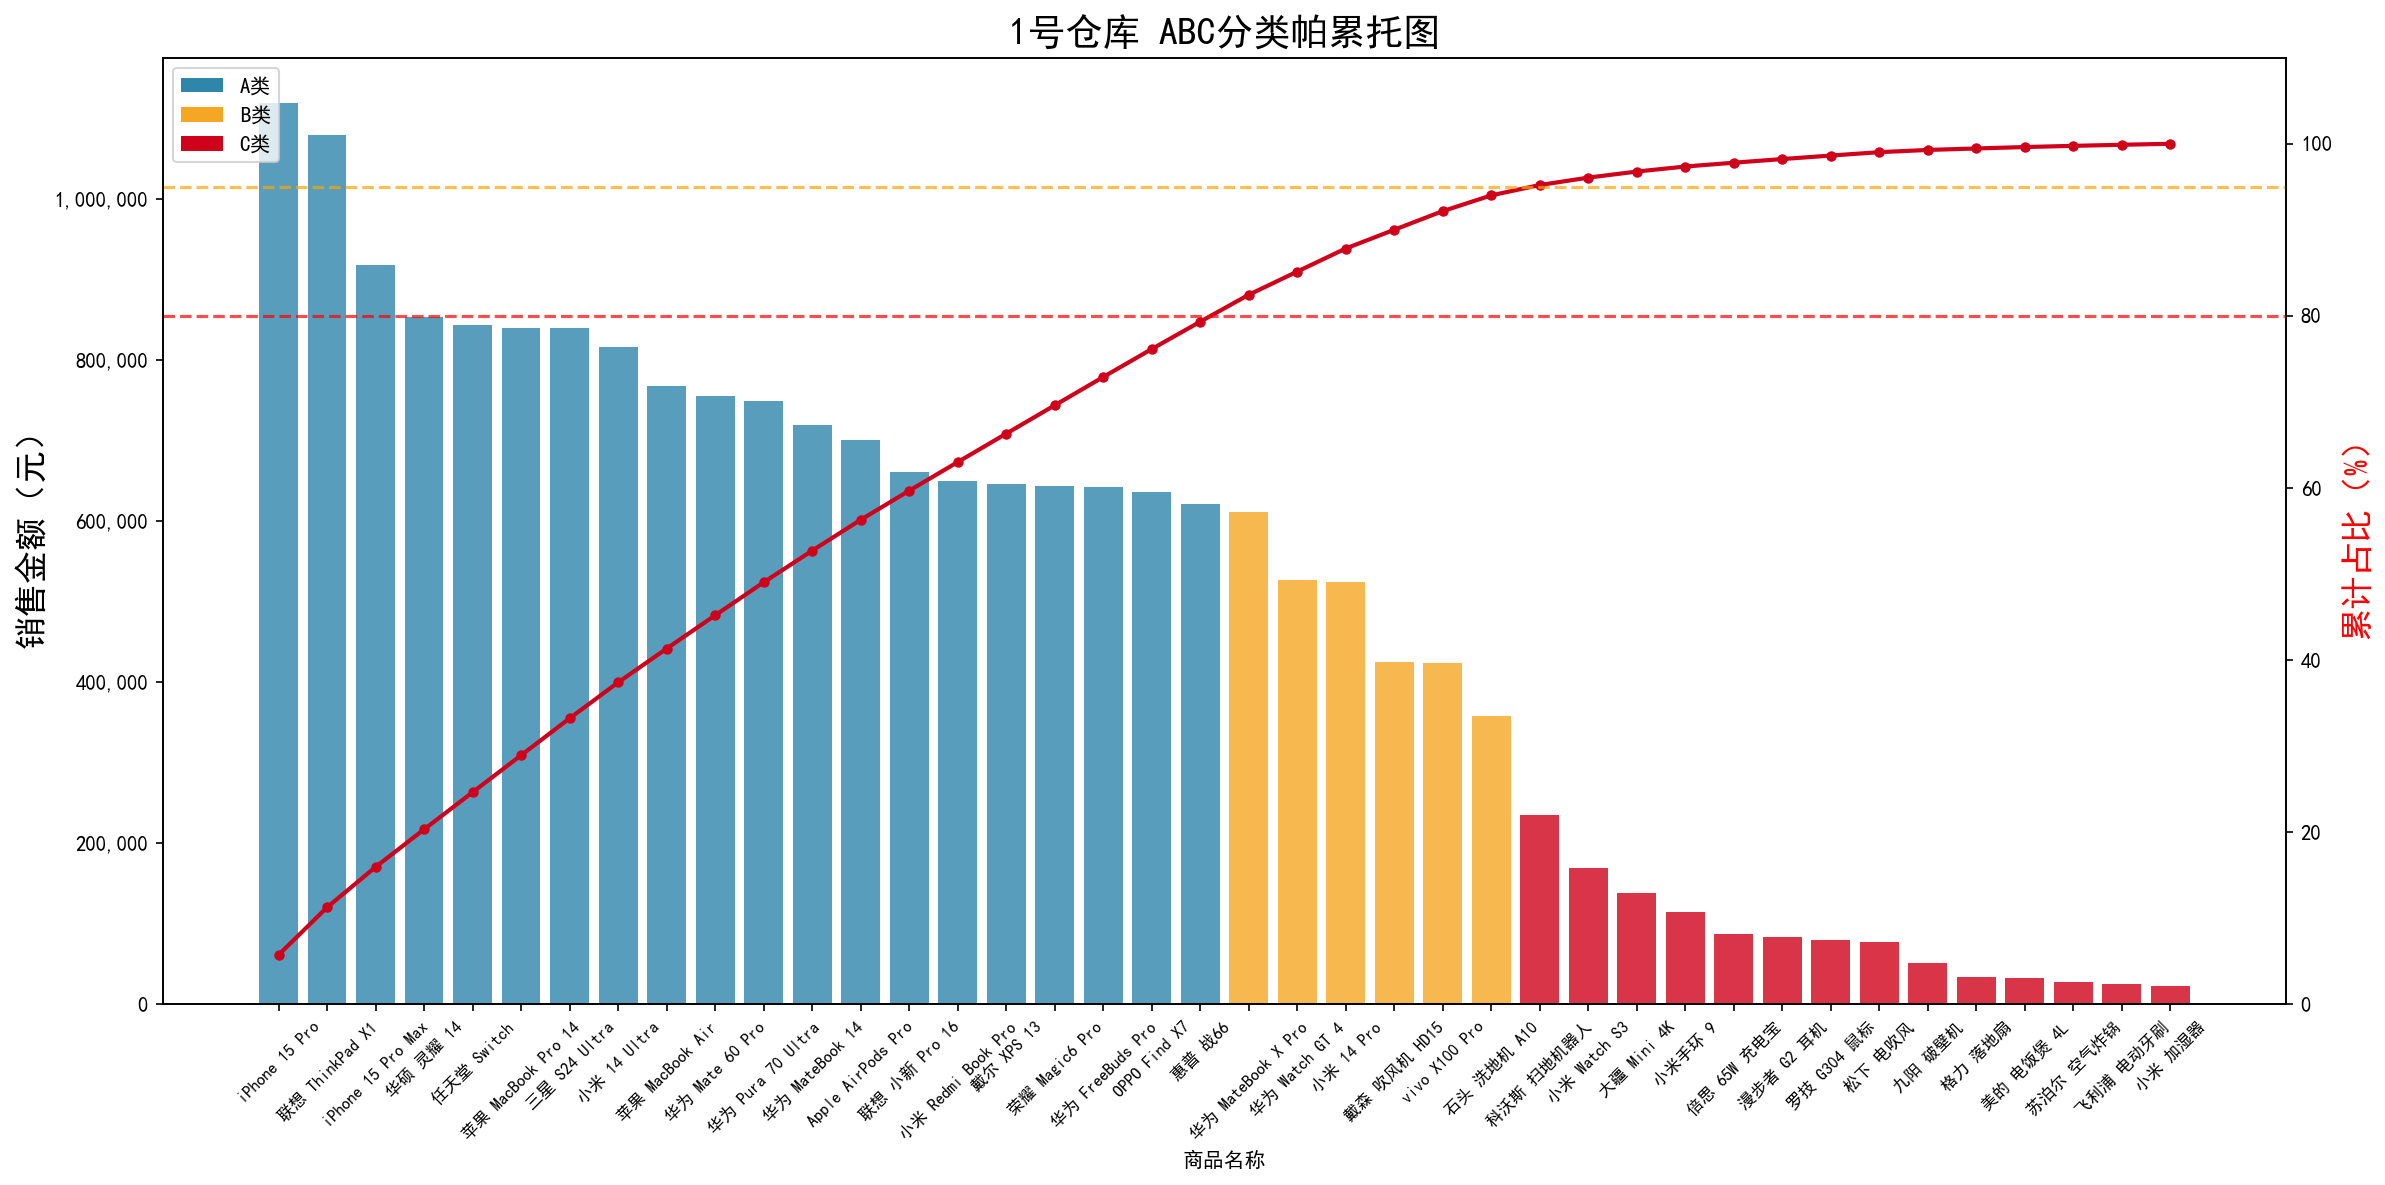

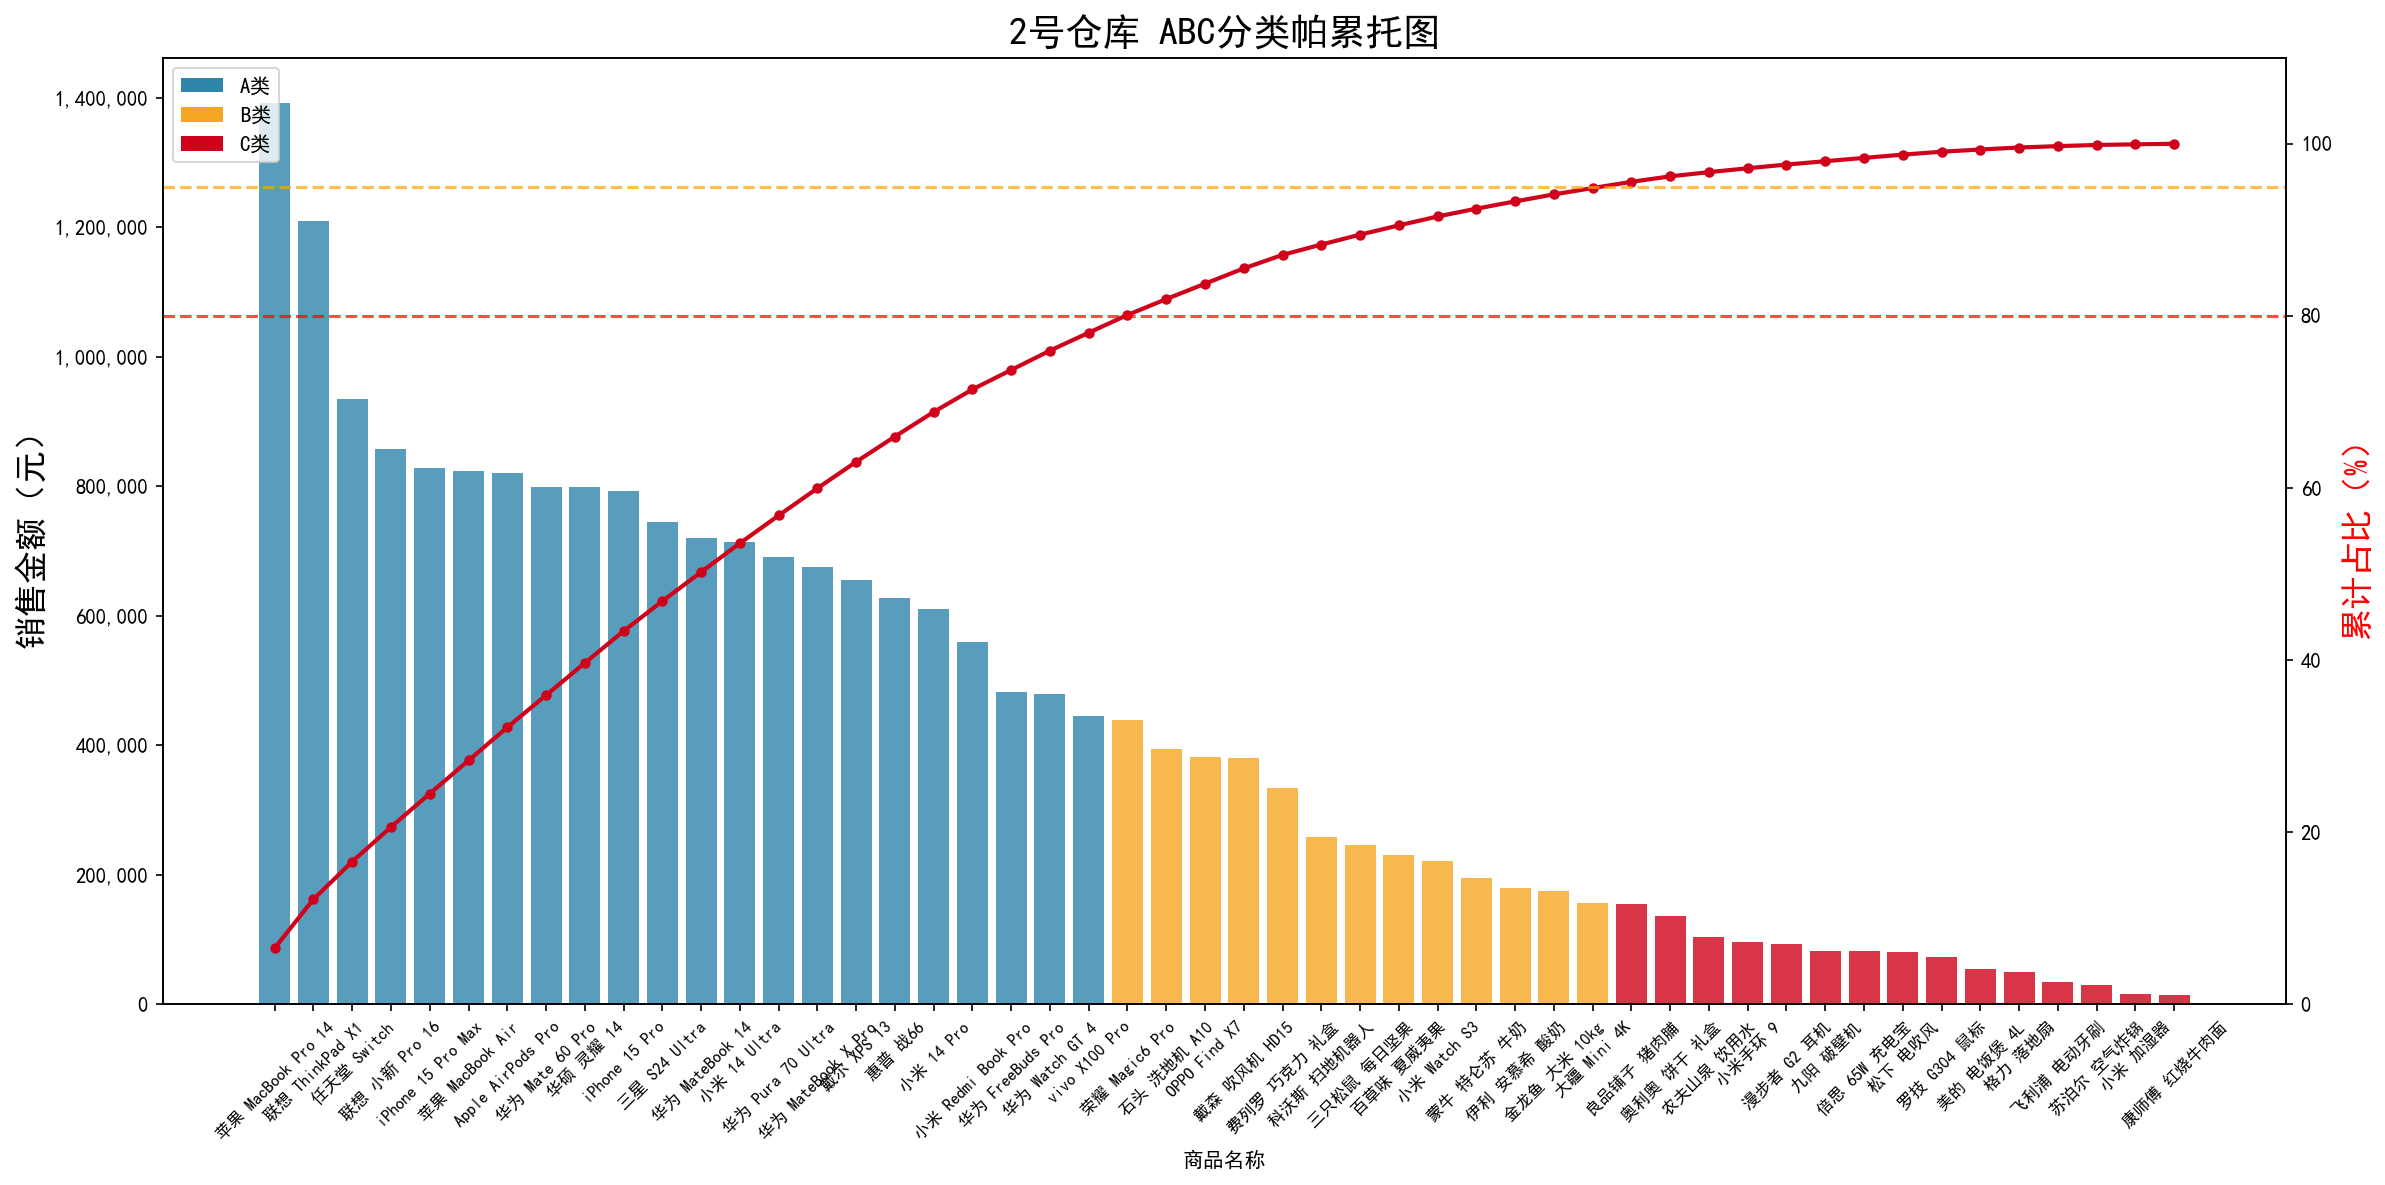

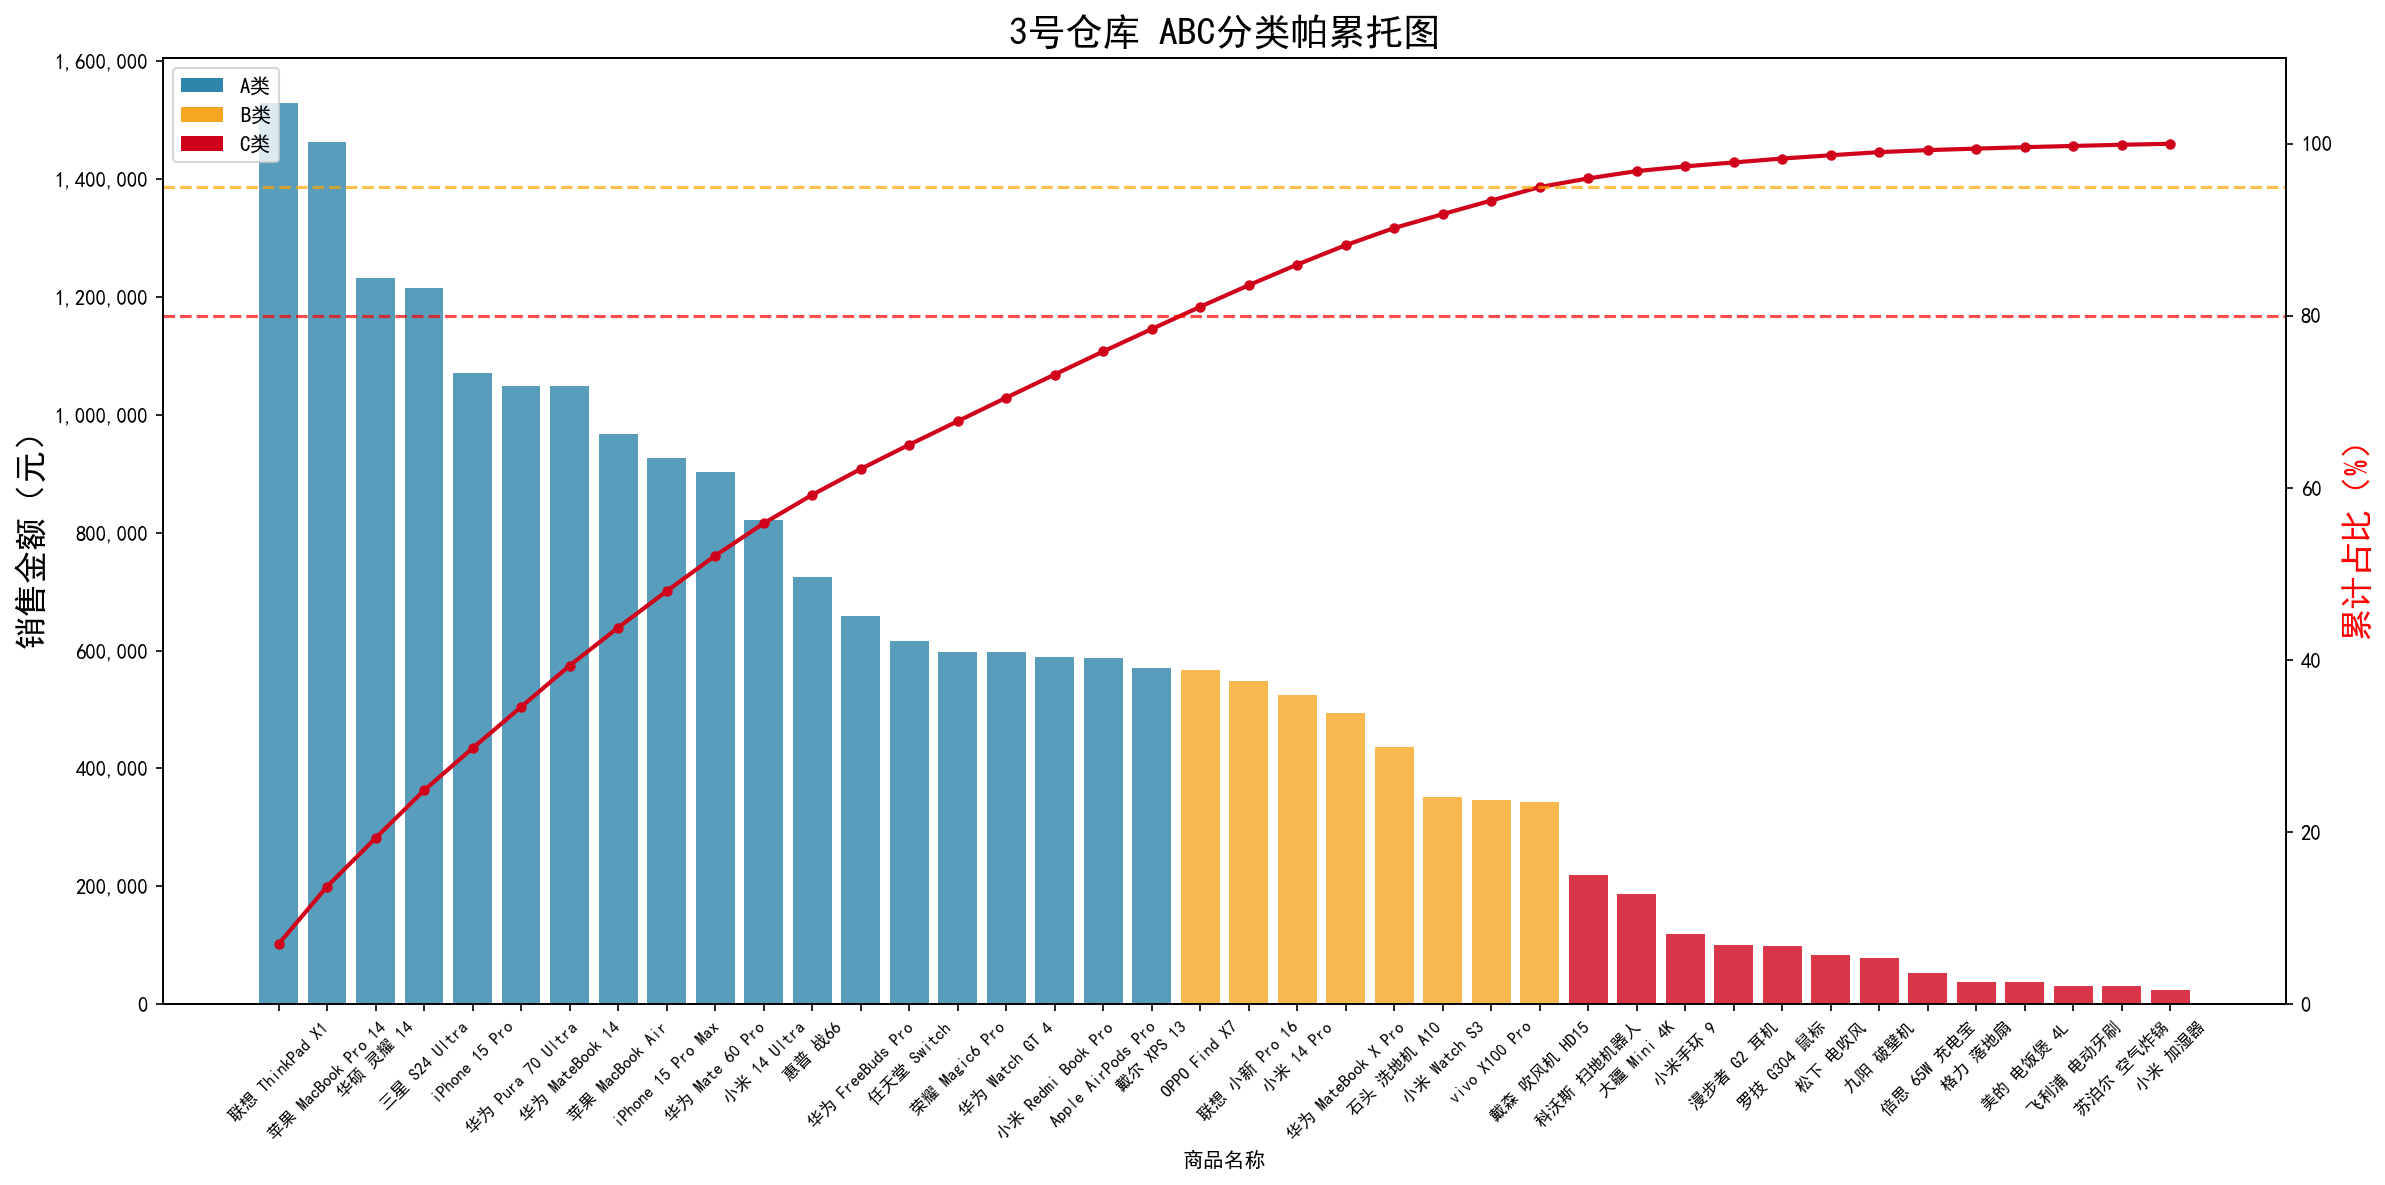

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# 设置中文字体
mpl.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
mpl.rcParams['axes.unicode_minus'] = False

#导入ABC分类结果
df_abc = pd.read_excel(r'C:\Users\LHN\Desktop\库存管理项目\ABC分类结果.xlsx', sheet_name='汇总')

#定义格式化函数：显示为普通数字
def format_normal(x, p):
    return f'{int(x):,}' 
    
#按仓库分别画图
for wh in [1, 2, 3]:
#筛选仓库
    df_wh = df_abc[df_abc['仓库ID'] == wh].copy()
    
#按累计占比排序
    df_wh = df_wh.sort_values('累计占比', ascending=True)
    
#创建图表
    fig, ax1 = plt.subplots(figsize=(16, 8),dpi=150)

#柱状图：销售额
    colors = df_wh['ABC分类'].map({'A类': '#2E86AB', 'B类': '#F5A623', 'C类': '#D0021B'})
    bars = ax1.bar(df_wh['商品名称'], df_wh['销售金额'], color=colors, alpha=0.8)
    ax1.set_xlabel('商品名称')
    ax1.set_ylabel('销售金额（元）', color='black',fontsize=16)
    ax1.tick_params(axis='x', rotation=45, labelsize=8)
#强制Y轴使用普通数字格式
    ax1.yaxis.set_major_formatter(FuncFormatter(format_normal))
    
#次坐标轴：累计占比折线图
    ax2 = ax1.twinx()
    ax2.plot(df_wh['商品名称'], df_wh['累计占比'] * 100, color='#D0021B', marker='o', linewidth=2, markersize=4)
    ax2.axhline(y=80, color='red', linestyle='--', alpha=0.7, label='80%基准线')
    ax2.axhline(y=95, color='orange', linestyle='--', alpha=0.7, label='95%基准线')
    ax2.set_ylabel('累计占比（%）', color='red',fontsize=16)
    ax2.set_ylim(0, 110)
    
#添加图例
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#2E86AB', label='A类'),
        Patch(facecolor='#F5A623', label='B类'),
        Patch(facecolor='#D0021B', label='C类')]
    ax1.legend(handles=legend_elements, loc='upper left')
    
#标题
    plt.title(f'{wh}号仓库 ABC分类帕累托图', fontsize=18)
    plt.tight_layout()
    plt.show()

周转率数据预览：
时间段    4月    5月   6月  Q2整体
仓库                        
1    0.25  0.27  1.5   1.9
2    0.31  0.34  2.1   2.5
3    0.29  0.35  2.0   2.4


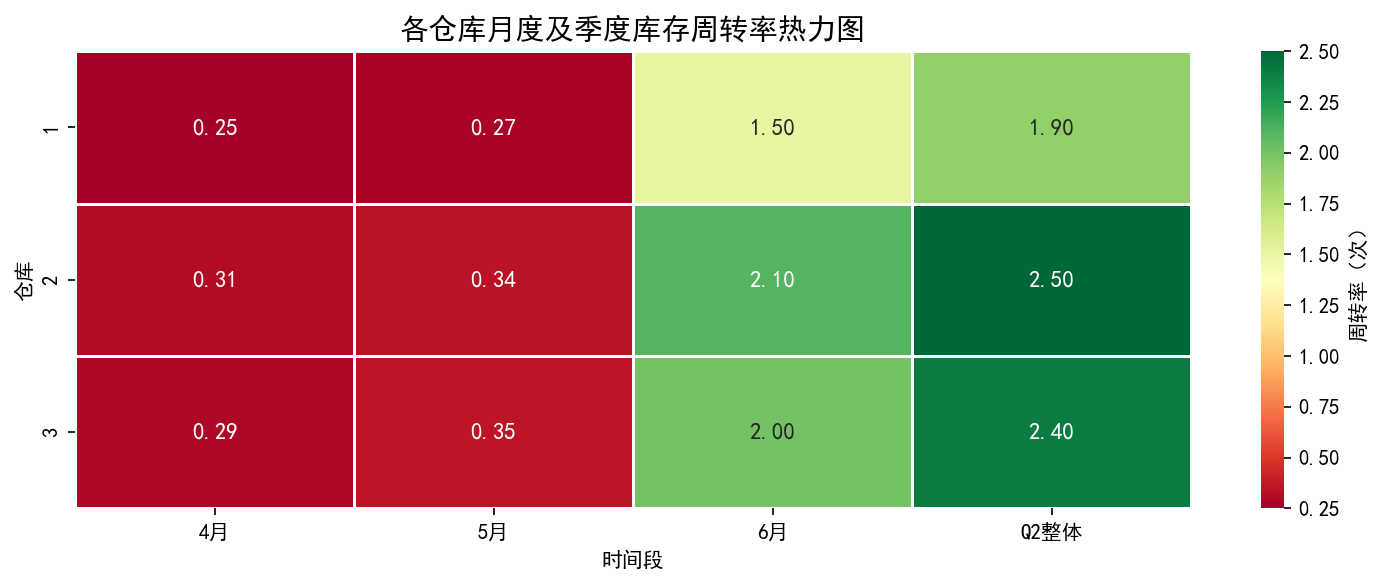

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import numpy as np

# 设置中文字体
mpl.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
mpl.rcParams['axes.unicode_minus'] = False

#导入周转率数据
data = {'仓库': [1, 1, 1, 1, 2, 2, 2, 2, 3, 3, 3, 3],
    '时间段': ['4月', '5月', '6月', 'Q2整体', '4月', '5月', '6月', 'Q2整体',
               '4月', '5月', '6月', 'Q2整体'],
    '周转率': [0.25, 0.27, 1.5, 1.9,0.31, 0.34, 2.1, 2.5,0.29, 0.35, 2.0, 2.4]}
df = pd.DataFrame(data)

#透视
pivot_matrix = df.pivot(index='仓库', columns='时间段', values='周转率')

time_order = ['4月', '5月', '6月', 'Q2整体']
pivot_matrix = pivot_matrix[time_order]

print("周转率数据预览：")
print(pivot_matrix)

#画热力图
fig, ax = plt.subplots(figsize=(10, 4),dpi=150)

sns.heatmap(
    pivot_matrix,
    annot=True,               
    fmt='.2f',                 
    cmap='RdYlGn',             
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': '周转率（次）'},
    ax=ax,
    annot_kws={'size': 11})

ax.set_title('各仓库月度及季度库存周转率热力图', fontsize=14)
ax.set_xlabel('时间段')
ax.set_ylabel('仓库')

plt.tight_layout()
plt.show()


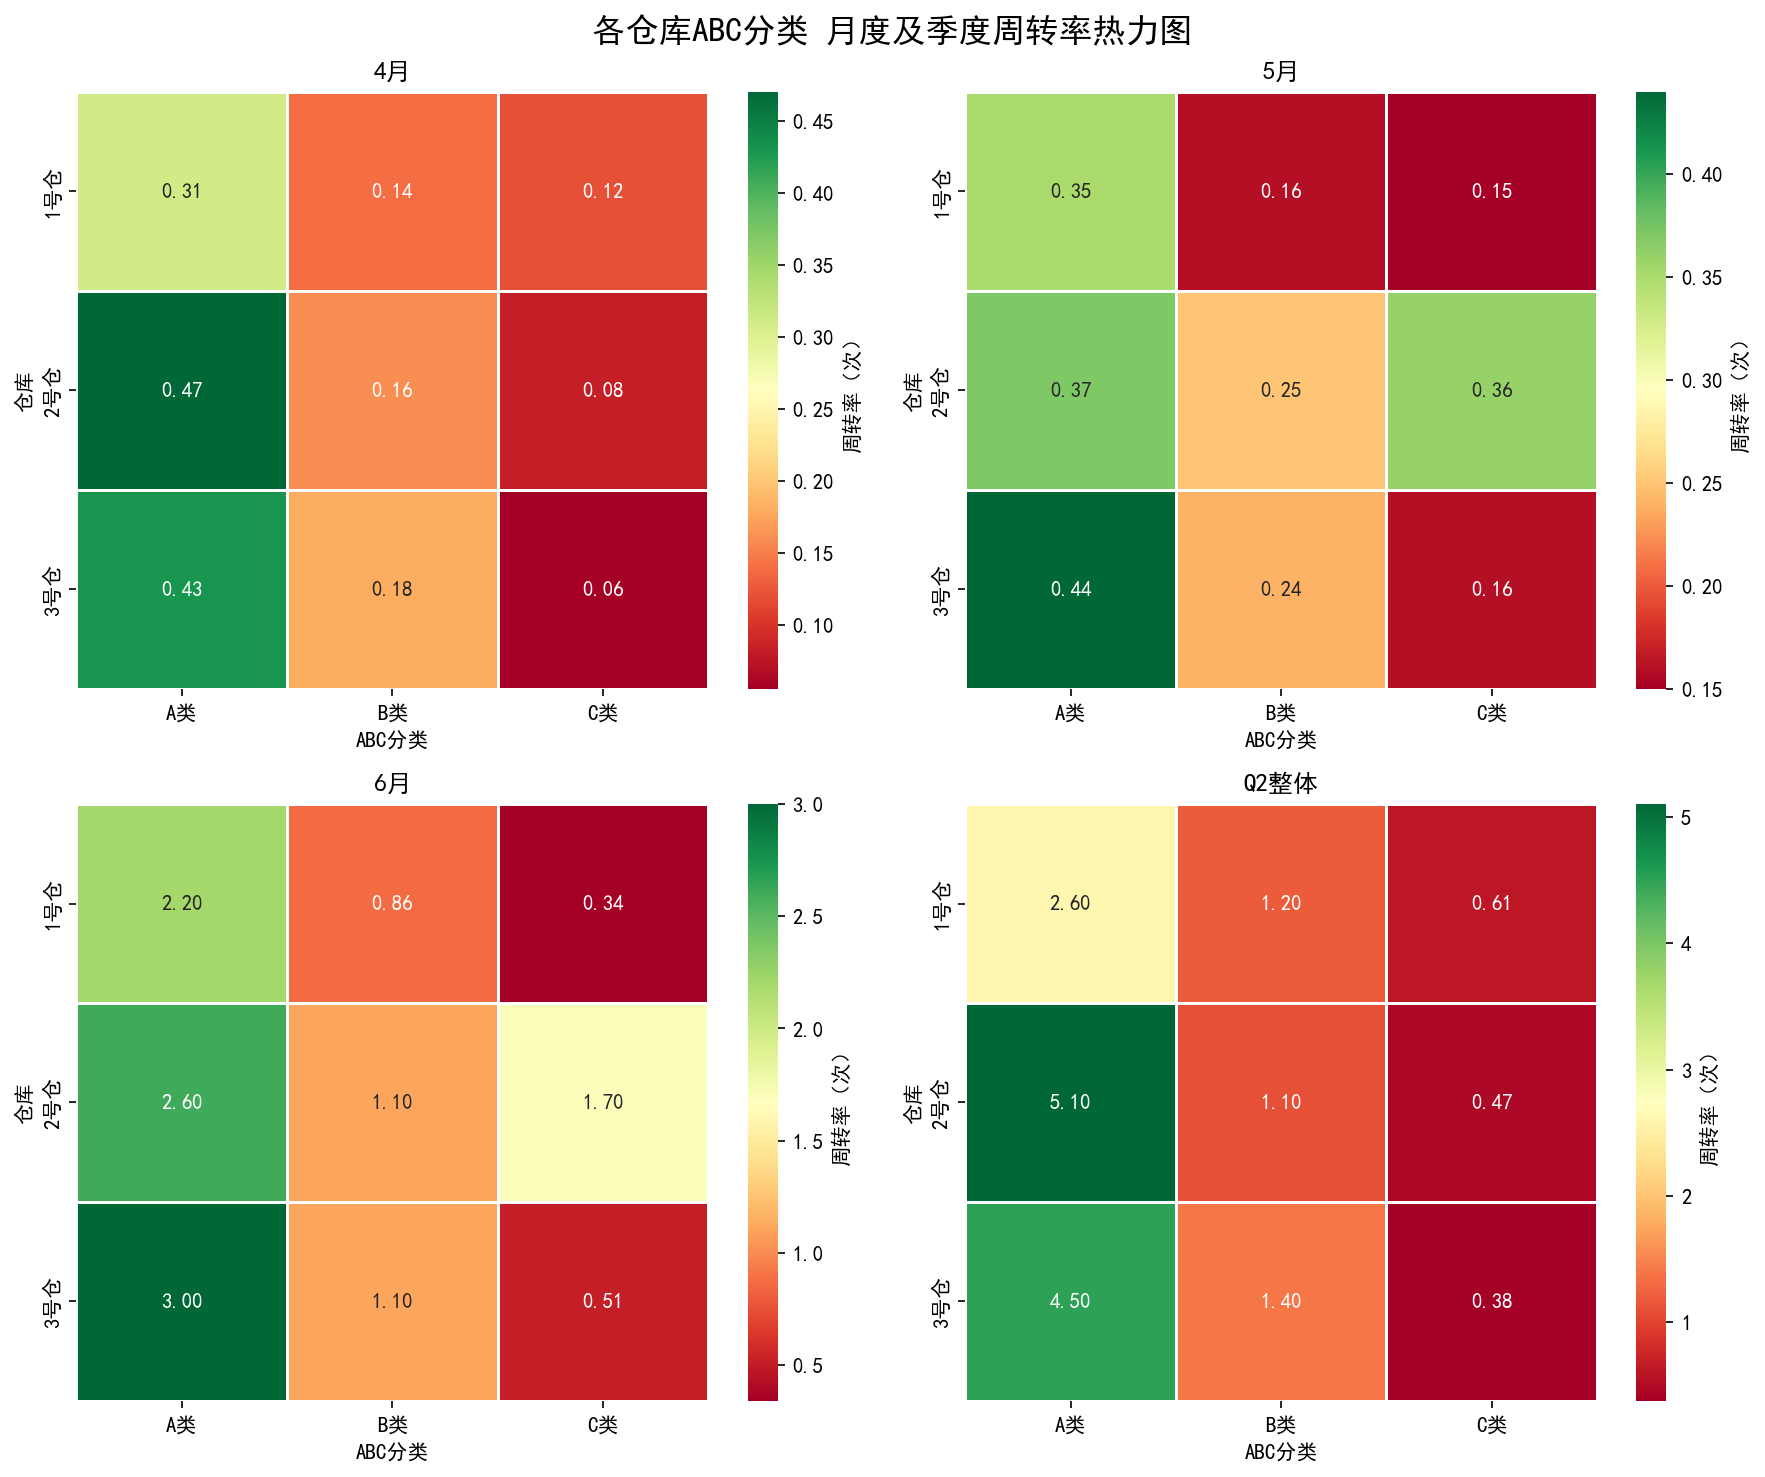

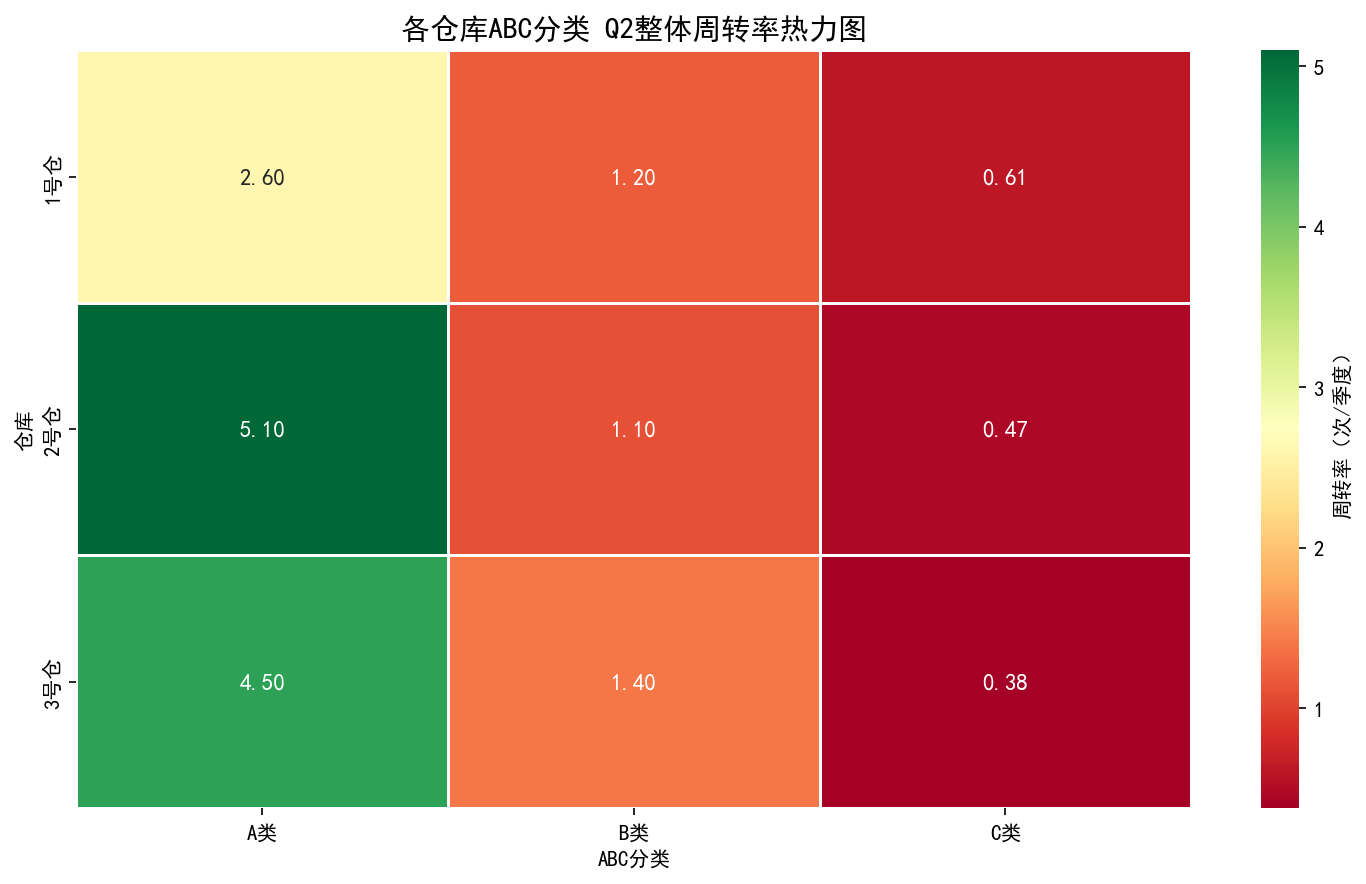

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

mpl.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
mpl.rcParams['axes.unicode_minus'] = False

#导入各仓库ABC分类周转率数据 
abc_data = {'仓库': [1, 1, 1, 2, 2, 2, 3, 3, 3],
    'ABC分类': ['A类', 'B类', 'C类', 'A类', 'B类', 'C类', 'A类', 'B类', 'C类'],
    '4月': [0.31, 0.14, 0.12, 0.47, 0.16, 0.082, 0.43, 0.18, 0.056],
    '5月': [0.35, 0.16, 0.15, 0.37, 0.25, 0.36, 0.44, 0.24, 0.16],
    '6月': [2.2, 0.86, 0.34, 2.6, 1.1, 1.7, 3.0, 1.1, 0.51],
    'Q2整体': [2.6, 1.2, 0.61, 5.1, 1.1, 0.47, 4.5, 1.4, 0.38]}

df_abc = pd.DataFrame(abc_data)

#按时间段分4张图
fig, axes = plt.subplots(2, 2, figsize=(12, 10),dpi=150)
time_periods = ['4月', '5月', '6月', 'Q2整体']

for idx, period in enumerate(time_periods):
    row = idx // 2
    col = idx % 2
    ax = axes[row, col]
    
#透视
    pivot = df_abc.pivot(index='仓库', columns='ABC分类', values=period)
    pivot.index = [f'{i}号仓' for i in pivot.index]
    
#画热力图
    sns.heatmap(
        pivot,
        annot=True,
        fmt='.2f',
        cmap='RdYlGn',
        linewidths=0.5,
        linecolor='white',
        cbar_kws={'label': '周转率（次）'},
        ax=ax,
        annot_kws={'size': 10} )
    ax.set_title(f'{period}', fontsize=12)
    ax.set_xlabel('ABC分类')
    ax.set_ylabel('仓库')

plt.suptitle('各仓库ABC分类 月度及季度周转率热力图', fontsize=16)
plt.tight_layout()
plt.show()

#画Q2整体的大图
fig, ax = plt.subplots(figsize=(10, 6),dpi=150)

pivot_q2 = df_abc.pivot(index='仓库', columns='ABC分类', values='Q2整体')
pivot_q2.index = [f'{i}号仓' for i in pivot_q2.index]

sns.heatmap(
    pivot_q2,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': '周转率（次/季度）'},
    ax=ax,
    annot_kws={'size': 11})

ax.set_title('各仓库ABC分类 Q2整体周转率热力图', fontsize=14)
ax.set_xlabel('ABC分类')
ax.set_ylabel('仓库')

plt.tight_layout()
plt.show()


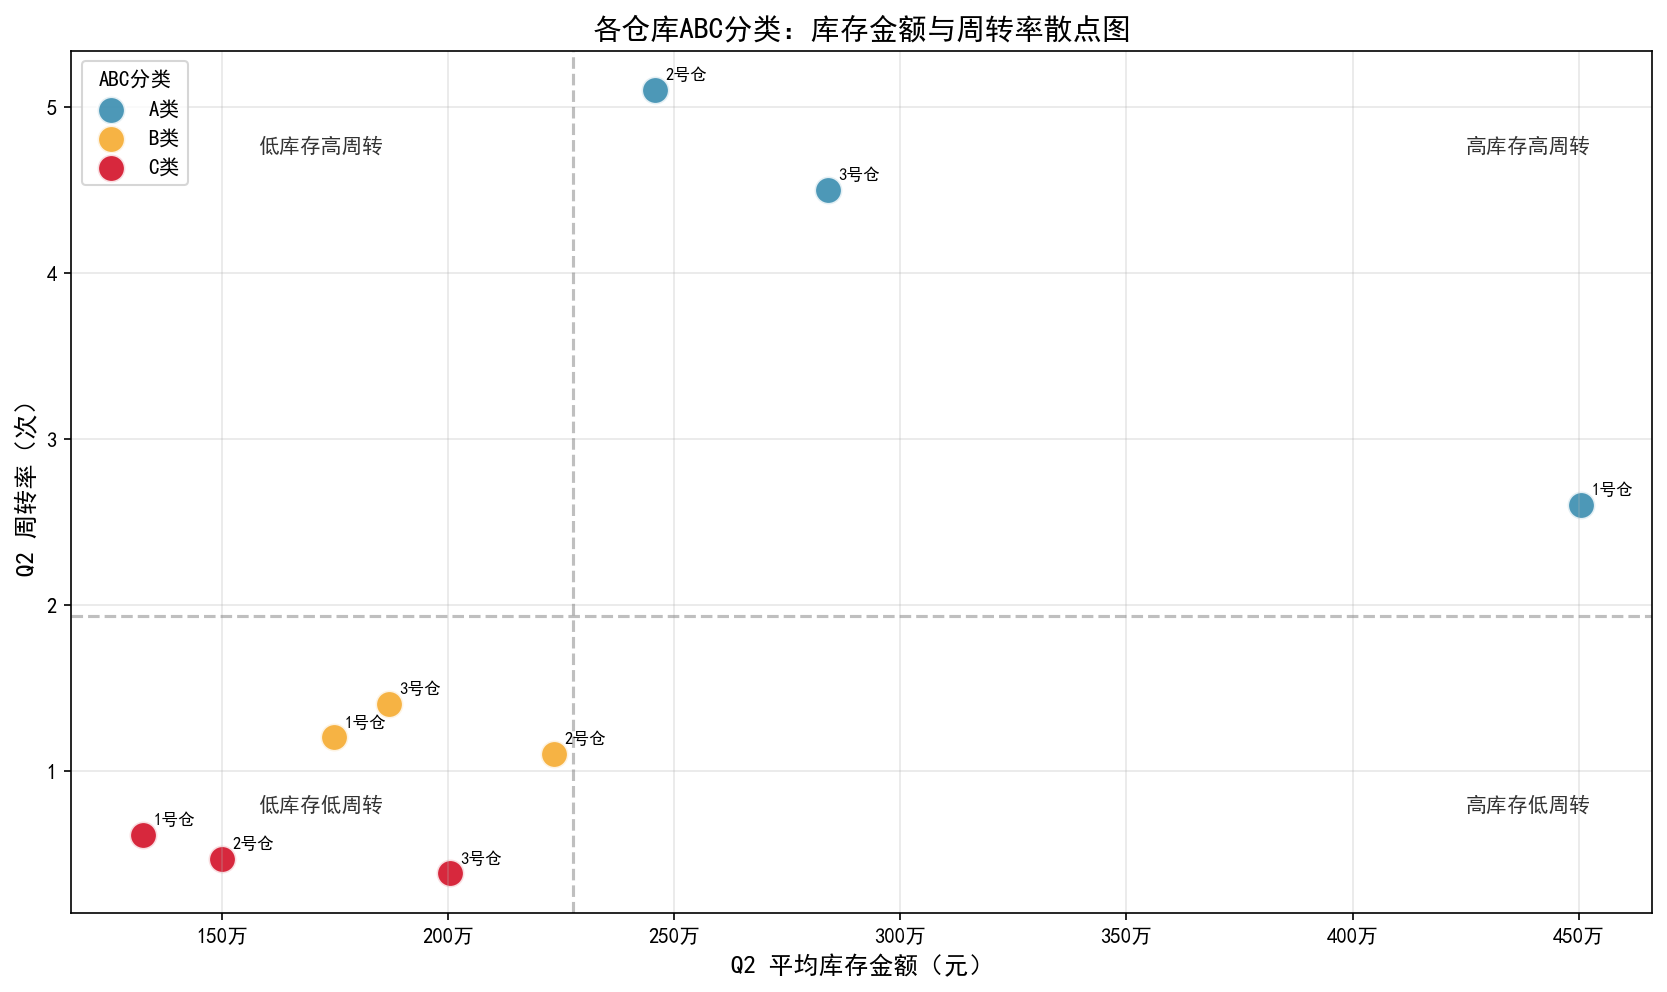

散点图数据摘要
 仓库ID ABC分类  Q2平均库存金额  Q2周转率
    1    A类 4504600.0   2.60
    1    B类 1747600.0   1.20
    1    C类 1325110.0   0.61
    2    A类 2456375.0   5.10
    2    B类 2233637.5   1.10
    2    C类 1500362.5   0.47
    3    A类 2839380.0   4.50
    3    B类 1869025.0   1.40
    3    C类 2002670.0   0.38

各ABC分类统计：
         Q2平均库存金额                       Q2周转率            
             mean        min        max  mean   min   max
ABC分类                                                    
A类     3266785.00  2456375.0  4504600.0  4.07  2.60  5.10
B类     1950087.50  1747600.0  2233637.5  1.23  1.10  1.40
C类     1609380.83  1325110.0  2002670.0  0.49  0.38  0.61


In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
mpl.rcParams['axes.unicode_minus'] = False

#导入数据
data = {
    '仓库ID': [1, 1, 1, 2, 2, 2, 3, 3, 3],
    'ABC分类': ['A类', 'B类', 'C类', 'A类', 'B类', 'C类', 'A类', 'B类', 'C类'],
    'Q2平均库存金额': [4504600.0, 1747600.0, 1325110.0, 2456375.0, 2233637.5, 1500362.5,2839380.0, 1869025.0, 2002670.0],
    'Q2周转率': [2.6, 1.2, 0.61, 5.1, 1.1, 0.47, 4.5, 1.4, 0.38]}
df = pd.DataFrame(data)

#画散点图 
fig, ax = plt.subplots(figsize=(11, 6.5), dpi=150, constrained_layout=True)
colors = {'A类': '#2E86AB', 'B类': '#F5A623', 'C类': '#D0021B'}

for abc in ['A类', 'B类', 'C类']:
    subset = df[df['ABC分类'] == abc]
    ax.scatter(subset['Q2平均库存金额'], subset['Q2周转率'],label=abc, color=colors[abc], s=180, alpha=0.85,
               edgecolors='white', linewidth=1.5)

#添加标签
for _, row in df.iterrows():
    ax.annotate(f"{int(row['仓库ID'])}号仓",(row['Q2平均库存金额'], row['Q2周转率']),xytext=(5, 5), textcoords='offset points',
                fontsize=8, fontweight='bold')

ax.set_xlabel('Q2 平均库存金额（元）', fontsize=12)
ax.set_ylabel('Q2 周转率（次）', fontsize=12)
ax.set_title('各仓库ABC分类：库存金额与周转率散点图', fontsize=14)
ax.legend(title='ABC分类', fontsize=10, loc='upper left')
ax.grid(True, alpha=0.3)

#参考线
avg_inv = df['Q2平均库存金额'].mean()
avg_turnover = df['Q2周转率'].mean()
ax.axvline(x=avg_inv, color='gray', linestyle='--', alpha=0.5)
ax.axhline(y=avg_turnover, color='gray', linestyle='--', alpha=0.5)

#X轴显示为万元
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/10000:.0f}万'))

#添加象限文字
#获取数据范围
min_inv = df['Q2平均库存金额'].min()
max_inv = df['Q2平均库存金额'].max()
min_turn = df['Q2周转率'].min()
max_turn = df['Q2周转率'].max()

#计算文字位置
pad_x = (max_inv - min_inv) * 0.08
pad_y = (max_turn - min_turn) * 0.08

ax.text(min_inv + pad_x, max_turn - pad_y, '低库存高周转', fontsize=10, alpha=0.8, fontweight='bold')
ax.text(min_inv + pad_x, min_turn + pad_y, '低库存低周转', fontsize=10, alpha=0.8, fontweight='bold')
ax.text(max_inv - pad_x, max_turn - pad_y, '高库存高周转', fontsize=10, alpha=0.8, fontweight='bold')
ax.text(max_inv - pad_x, min_turn + pad_y, '高库存低周转', fontsize=10, alpha=0.8, fontweight='bold')

plt.show()

#打印数据摘要 
print("散点图数据摘要")
print("=" * 50)
print(df.to_string(index=False))

#各ABC分类的统计
print("\n各ABC分类统计：")
print(df.groupby('ABC分类').agg({'Q2平均库存金额': ['mean', 'min', 'max'],
                               'Q2周转率': ['mean', 'min', 'max']}).round(2))
